In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)
import random
import optuna
import torch.optim as optim
import time
import torch.nn.functional as F
import os

# Data

In [2]:
df = pd.read_csv('./data/prepared_data_mill13.csv')
df['average_time'] = pd.to_datetime(df['average_time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values(by='average_time')
df = df.reset_index(drop=True)
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850


In [3]:
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
INITIAL_BAUXITE = 7 # исходное количество боксита в мельнице, т

# Параметры для расчета объема пульпы в мельнице
FILL_RATE = 0.45  # доля заполнения мельницы
BALL_MASS = 60  # масса мелящих шаров, т
MILL_VOLUME = 36  # объем мельницы, м3
MILL_LENGTH = 4.5 # длина мельницы, м
STEEL_DENSITY = 7800  # плотность стали, кг/м3
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
WATER_DENSITY = 1000 # плотность воды, кг/м3

# -- Для Розина-Раммлера --
D1 = 0.056 # диаметр сита, мм
D2 = 0.16 # диаметр сита, мм

# объём шаров, м3
BALL_VOLUME = BALL_MASS * 1000 / STEEL_DENSITY

# Объём пульпы (боксит+вода+раствор), м3
SLURRY_VOLUME = MILL_VOLUME * FILL_RATE - BALL_VOLUME

# Площадь сечения мельницы, м2
MILL_AREA =  MILL_VOLUME / MILL_LENGTH

# Площадь сечения пульпы, м2
F_SLURRY = SLURRY_VOLUME / MILL_LENGTH

# epsilon для вычисления скорости
EPS = 1-(BALL_VOLUME/MILL_VOLUME)

In [4]:
S_max = 750

# Вычисление v

In [5]:
import numpy as np

def mean_filter(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')


df['Qsolid_[m3/h]'] = df['Q_bauxite_[t/h]'] * 0.9 * 1000 / BAUXITE_DENSITY 
df['Qliquid_[m3/h]'] = (df['Q_bauxite_[t/h]'] * 0.1 * 1000 / WATER_DENSITY) + df['Q_liquid_mill13_[m3/h]'] # Вычисление жидкой составляющей
df['V_[m/s]'] = EPS * (df['Qsolid_[m3/h]']+df['Qliquid_[m3/h]']) / (F_SLURRY * 3600)
df['residence_time_[s]'] = MILL_LENGTH / df['V_[m/s]']

# MEAN FILTER
df['mean_S_[m2/kg]'] = mean_filter(df['S_[m2/kg]'].to_numpy(), window_size=7)

df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349


In [7]:
df.to_csv("data_final.csv", index=False)

In [6]:
df.describe()

,Unnamed: 0,Q_bauxite_[t/h],Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
count,177.000000,175.000000,177.000000,177.000000,177.000000,177.000000,177,177.000000,177.000000,177.000000,177.000000,175.000000,175.000000,175.000000,175.000000,177.000000
mean,88.576271,69.851291,49.660452,3.594915,20.679322,62.604463,2023-05-21 08:08:14.915254,0.626045,0.793207,0.085557,248.561597,22.452201,56.532558,0.009125,499.172780,247.262246
min,0.000000,29.085400,31.600000,1.300000,3.910000,17.470000,2023-01-03 08:42:30,0.174700,0.502000,0.016907,6.138922,9.348879,41.733030,0.006635,354.862422,77.045933
25%,44.000000,57.169150,46.800000,2.900000,15.790000,57.710000,2023-03-20 11:19:00,0.577100,0.746600,0.039683,158.777292,18.375798,53.403010,0.008412,463.296897,202.627966
50%,88.000000,68.048500,49.400000,3.500000,20.120000,63.390000,2023-04-28 13:43:30,0.633900,0.798800,0.055416,222.177075,21.872732,56.370570,0.009064,496.463547,245.048961
75%,134.000000,80.149450,52.100000,4.200000,25.340000,69.030000,2023-06-20 11:44:30,0.690300,0.842100,0.077543,310.261934,25.762323,59.328130,0.009713,534.957322,289.023029
max,178.000000,155.165900,69.900000,6.600000,49.800000,82.400000,2023-12-09 17:15:00,0.824000,0.960900,2.005580,728.239346,49.874754,72.494390,0.012681,678.200077,367.370992
std,51.950655,18.000133,5.099289,0.847675,7.443997,10.182559,NaN,0.101826,0.074440,0.176219,137.937491,5.785757,5.125208,0.001018,55.141431,61.026551


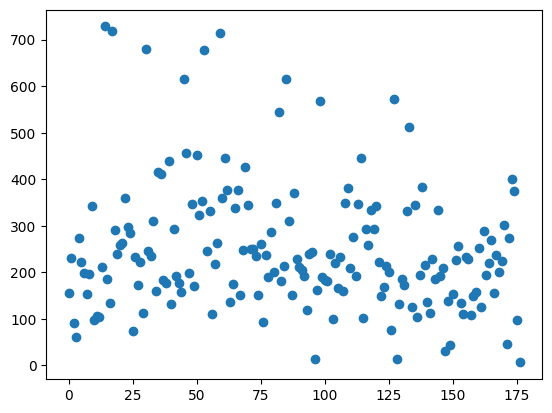

In [7]:
plt.scatter(range(len(df)), df["S_[m2/kg]"])
plt.show()

## Генерация датасета

In [38]:
s_in = 0.5 #m2/kg боксит на входе в мельницу
z_max = 4.5 / 4.5
v_max = max(df['V_[m/s]'])
n_pde = 100
s_0 = 10. #m2/kg боксит вов ремя начала работы мельницы
t_max = (df['average_time'][len(df)-1] - df['average_time'][0]).total_seconds()
# t_max = 500.

In [39]:
df['k'] = -df['V_[m/s]']/z_max * np.log((S_max-df['S_[m2/kg]']) / (S_max-s_in))

In [40]:
data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "v_bc1_train": [],
    "k_bc1_train": [],
    "S_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "v_bc2_train": [],
    "k_bc2_train": [],
    "S_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],
    "k_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    "k_ic_train": [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "v_bc1_test": [],
    "k_bc1_test": [],
    "S_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "v_bc2_test": [],
    "k_bc2_test": [],
    "S_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],
    "k_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    "k_ic_test": [],
    'S_ic_test': [],
}

# --- Генерация тренировочных данных ---
for i, row in df[:101].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        t = row['average_time'] - df['average_time'][0] #
        t = t.total_seconds() / t_max # seconds
        # t = row['residence_time_[s]']
        v = row['V_[m/s]']  / v_max
        # s = row['S_[m2/kg]']  / 728.239346
        s = row['mean_S_[m2/kg]']
        k = row['k']
        
        # -- Начало мельницы ---
        data['t_bc1_train'].append(t)
        data['z_bc1_train'].append(0)
        data['v_bc1_train'].append(v)
        data['k_bc1_train'].append(k)
        data['S_bc1_train'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_train'].append(t)
        data['z_bc2_train'].append(z_max)
        data['v_bc2_train'].append(v)
        data['k_bc2_train'].append(k)
        data['S_bc2_train'].append(s)

        # -- Initinal condition
        data['t_ic_train'].append(0)
        data['z_ic_train'].append(z_max)
        data['v_ic_train'].append(v)
        data['k_ic_train'].append(k)
        data['S_ic_train'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_train'].append(t)
            data['z_pde_train'].append(random.random()*z_max)
            data['v_pde_train'].append(v)
            data['k_pde_train'].append(k)

# --- Генерация тестовых данных ---
for i, row in df[101:].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        t = row['average_time'] - df['average_time'][0] 
        t = t.total_seconds() / t_max # seconds
        # t = row['residence_time_[s]']
        v = row['V_[m/s]'] #/ v_max
        # s = row['S_[m2/kg]'] # / 728.239346
        s = row['mean_S_[m2/kg]']
        k = row['k']
        
        # -- Начало мельницы ---
        data['t_bc1_test'].append(t)
        data['z_bc1_test'].append(0)
        data['v_bc1_test'].append(v)
        data['k_bc1_test'].append(k)
        data['S_bc1_test'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_test'].append(t)
        data['z_bc2_test'].append(z_max)
        data['v_bc2_test'].append(v)
        data['k_bc2_test'].append(k)
        data['S_bc2_test'].append(s)

        # -- initinal --
        data['t_ic_test'].append(0)
        data['z_ic_test'].append(z_max)
        data['v_ic_test'].append(v)
        data['k_ic_test'].append(k)
        data['S_ic_test'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_test'].append(t)
            data['z_pde_test'].append(random.random()*z_max)
            data['v_pde_test'].append(v)
            data['k_pde_test'].append(k)

In [81]:
df.iloc[101, 2]

'2023-05-17'

In [80]:
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg],k
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933,0.001963
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314,0.002942
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896,0.001144
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924,0.000815
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450,0.004726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492,0.003424
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621,0.006955
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573,0.006649
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349,0.001333


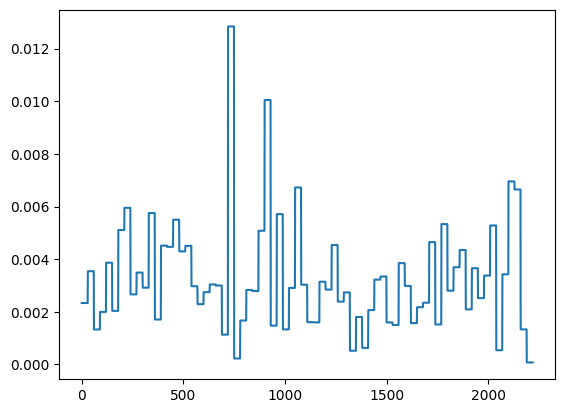

In [159]:
plt.plot(data['k_pde_test'])

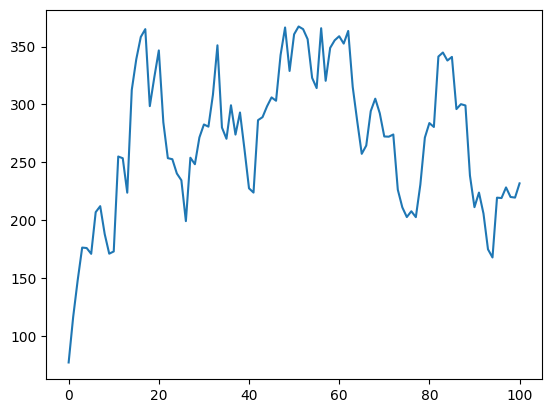

In [27]:
plt.plot(data['S_bc2_train'])

In [17]:
import random

In [37]:
valid_indices = df[df["Q_bauxite_[t/h]"].notna()].index.tolist()

# Перемешать
rng = random.Random(42)
rng.shuffle(valid_indices)

# Разбить (пример: 80% train, 20% test;
n_total = len(valid_indices)
n_train = int(0.8 * n_total)  
train_idx = valid_indices[:n_train]
test_idx  = valid_indices[n_train:]

data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "v_bc1_train": [],
    "k_bc1_train": [],
    "S_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "v_bc2_train": [],
    "k_bc2_train": [],
    "S_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],
    "k_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    "k_ic_train": [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "v_bc1_test": [],
    "k_bc1_test": [],
    "S_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "v_bc2_test": [],
    "k_bc2_test": [],
    "S_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],
    "k_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    "k_ic_test": [],
    'S_ic_test': [],
}   

# 4. Генерация train
for i in train_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_train'].append(t)
    data['z_bc1_train'].append(0)
    data['v_bc1_train'].append(v)
    data['k_bc1_train'].append(k)
    data['S_bc1_train'].append(s_in)

    data['t_bc2_train'].append(t)
    data['z_bc2_train'].append(z_max)
    data['v_bc2_train'].append(v)
    data['k_bc2_train'].append(k)
    data['S_bc2_train'].append(s)

    data['t_ic_train'].append(0)
    data['z_ic_train'].append(z_max)
    data['v_ic_train'].append(v)
    data['k_ic_train'].append(k)
    data['S_ic_train'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_train'].append(rng.random() * t_max)
        data['z_pde_train'].append(rng.random() * z_max)
        data['v_pde_train'].append(v)
        data['k_pde_train'].append(k)

for i in test_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_test'].append(t)
    data['z_bc1_test'].append(0)
    data['v_bc1_test'].append(v)
    data['k_bc1_test'].append(k)
    data['S_bc1_test'].append(s_in)

    data['t_bc2_test'].append(t)
    data['z_bc2_test'].append(z_max)
    data['v_bc2_test'].append(v)
    data['k_bc2_test'].append(k)
    data['S_bc2_test'].append(s)

    data['t_ic_test'].append(0)
    data['z_ic_test'].append(z_max)
    data['v_ic_test'].append(v)
    data['k_ic_test'].append(k)
    data['S_ic_test'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_test'].append(rng.random() * t_max)
        data['z_pde_test'].append(rng.random() * z_max)
        data['v_pde_test'].append(v)
        data['k_pde_test'].append(k)

# Преобразование в нужный для PINN вид

In [7]:
from loss.pinn_loss_v2 import pinn_loss_v2
from networks.PINN_v2 import PINN_v2

In [57]:
pinn = PINN_v2(k=0.00189)

optimizer = optim.Adam(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(5_000):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=2.0, 
        lambda_bc1=1.0, 
        lambda_bc2=3.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 9520.967 | k = 0.00189
Loss PDE: 2124.871 | Loss BC1: 148.990 | Loss BC2: 1707.411
--------------------------------------------------
Epoch 100 | Loss: 9242.542 | k = 0.00189
Epoch 200 | Loss: 9234.010 | k = 0.00189
Epoch 300 | Loss: 9223.908 | k = 0.00189
Epoch 400 | Loss: 9219.276 | k = 0.00189
Epoch 500 | Loss: 9206.211 | k = 0.00189
Epoch 600 | Loss: 9195.721 | k = 0.00189
Epoch 700 | Loss: 9182.769 | k = 0.00189
Epoch 800 | Loss: 9168.573 | k = 0.00189
Epoch 900 | Loss: 9153.246 | k = 0.00189
Epoch 1000 | Loss: 9133.646 | k = 0.00189
Loss PDE: 1878.712 | Loss BC1: 246.884 | Loss BC2: 1709.779
--------------------------------------------------
Epoch 1100 | Loss: 9121.369 | k = 0.00189
Epoch 1200 | Loss: 9094.544 | k = 0.00189
Epoch 1300 | Loss: 9075.057 | k = 0.00189
Epoch 1400 | Loss: 9054.019 | k = 0.00189
Epoch 1500 | Loss: 9027.461 | k = 0.00189
Epoch 1600 | Loss: 9003.262 | k = 0.00189
Epoch 1700 | Loss: 8973.598 | k = 0.

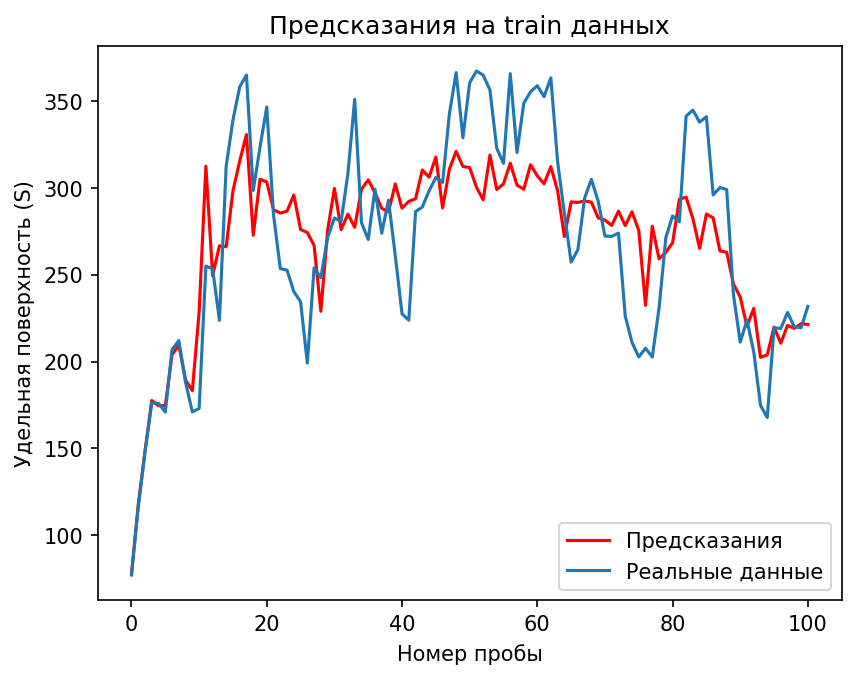

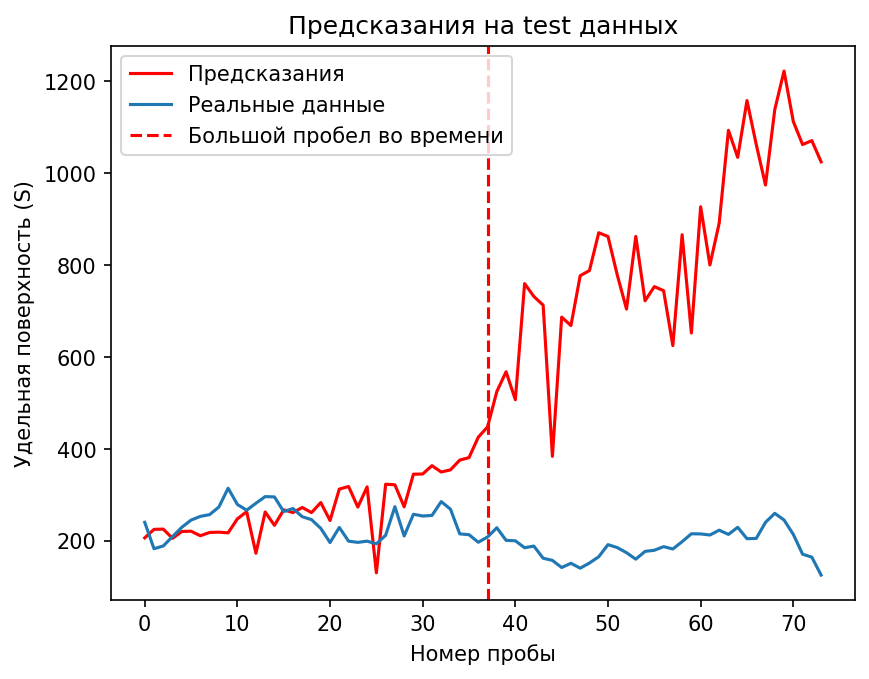

In [58]:
plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        # torch.tensor(data['k_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        # torch.tensor(data['k_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [60]:
torch.save({
                'model_state_dict': pinn.state_dict(),
            }, "pinn_2605.pt")

# Время - время пребывания

In [59]:
# pinn = PINN_v2(k=0.001)

optimizer = optim.Adam(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(5_000):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=1.0, 
        lambda_bc1=0.0, 
        lambda_bc2=0.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 0.001 | k = 0.00100
Loss PDE: 0.001 | Loss BC1: 62607.137 | Loss BC2: 3650.712
--------------------------------------------------
Epoch 100 | Loss: 0.005 | k = 0.00100
Epoch 200 | Loss: 0.004 | k = 0.00100
Epoch 300 | Loss: 0.004 | k = 0.00100
Epoch 400 | Loss: 0.004 | k = 0.00100
Epoch 500 | Loss: 0.003 | k = 0.00100
Epoch 600 | Loss: 0.003 | k = 0.00100
Epoch 700 | Loss: 0.002 | k = 0.00100
Epoch 800 | Loss: 0.002 | k = 0.00100
Epoch 900 | Loss: 0.001 | k = 0.00100
Epoch 1000 | Loss: 0.001 | k = 0.00100
Loss PDE: 0.001 | Loss BC1: 63663.457 | Loss BC2: 3696.859
--------------------------------------------------
Epoch 1100 | Loss: 0.001 | k = 0.00100
Epoch 1200 | Loss: 0.001 | k = 0.00100
Epoch 1300 | Loss: 0.001 | k = 0.00100
Epoch 1400 | Loss: 0.001 | k = 0.00100
Epoch 1500 | Loss: 0.001 | k = 0.00100
Epoch 1600 | Loss: 0.001 | k = 0.00100
Epoch 1700 | Loss: 0.001 | k = 0.00100
Epoch 1800 | Loss: 0.001 | k = 0.00100
Epoch 1900 

Обучение PINN c k

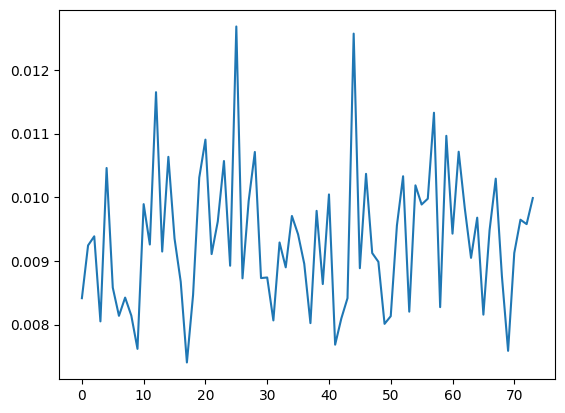

In [96]:
plt.plot(data['v_bc2_test'])

In [ ]:
pinn = PINN_v2(k=0.00189)

optimizer = optim.Adam(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(10_000):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=2.0, 
        lambda_bc1=1.0, 
        lambda_bc2=3.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


**Обучение простой ANN**

In [69]:
# model = PINN_v2(k=3e-3)
ann = PINN_v2(k=0.00189)

optimizer = optim.Adam(ann.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(5_000):
    ann.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        ann,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=0.0, 
        lambda_bc1=0.0, 
        lambda_bc2=1.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {ann.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = ann(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 77124.406 | k = 0.00189
Loss PDE: 2.004 | Loss BC1: 0.270 | Loss BC2: 77124.406
--------------------------------------------------
Epoch 100 | Loss: 4036.788 | k = 0.00189
Epoch 200 | Loss: 3985.089 | k = 0.00189
Epoch 300 | Loss: 3939.809 | k = 0.00189
Epoch 400 | Loss: 3893.917 | k = 0.00189
Epoch 500 | Loss: 3849.217 | k = 0.00189
Epoch 600 | Loss: 3806.487 | k = 0.00189
Epoch 700 | Loss: 3765.905 | k = 0.00189
Epoch 800 | Loss: 3727.351 | k = 0.00189
Epoch 900 | Loss: 3690.640 | k = 0.00189
Epoch 1000 | Loss: 3656.093 | k = 0.00189
Loss PDE: 357.612 | Loss BC1: 24946.490 | Loss BC2: 3656.093
--------------------------------------------------
Epoch 1100 | Loss: 3625.054 | k = 0.00189
Epoch 1200 | Loss: 3599.572 | k = 0.00189
Epoch 1300 | Loss: 3581.674 | k = 0.00189
Epoch 1400 | Loss: 3571.590 | k = 0.00189
Epoch 1500 | Loss: 3567.216 | k = 0.00189
Epoch 1600 | Loss: 3565.752 | k = 0.00189
Epoch 1700 | Loss: 3565.361 | k = 0.00

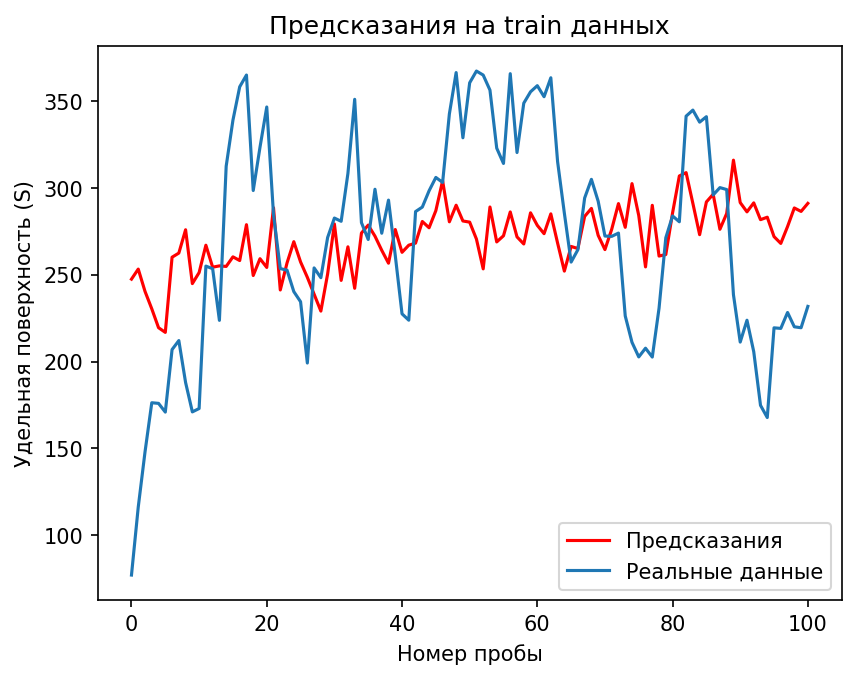

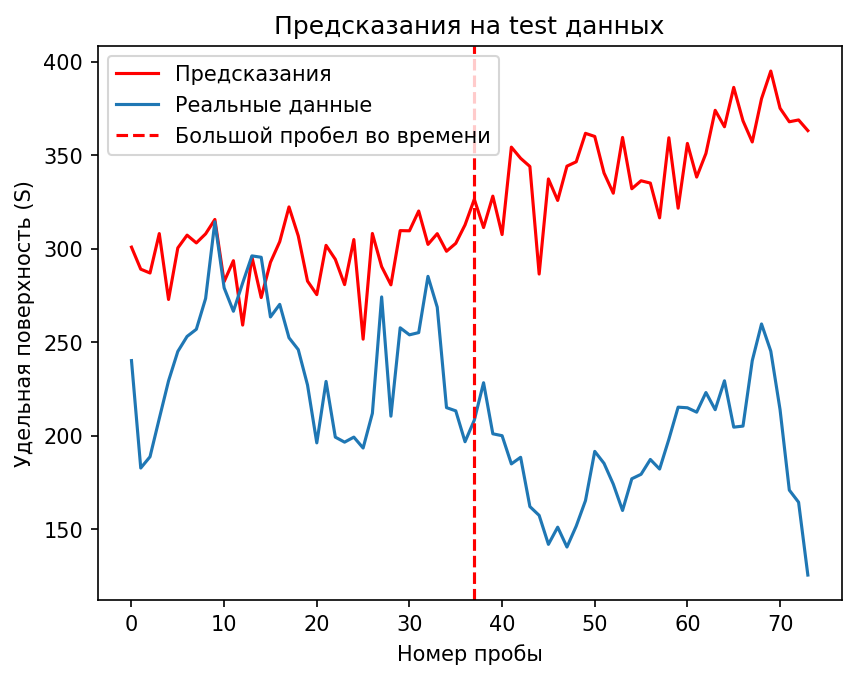

In [70]:
plt.figure(dpi=150)
plt.plot(ann(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        # torch.tensor(data['k_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(ann(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        # torch.tensor(data['k_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

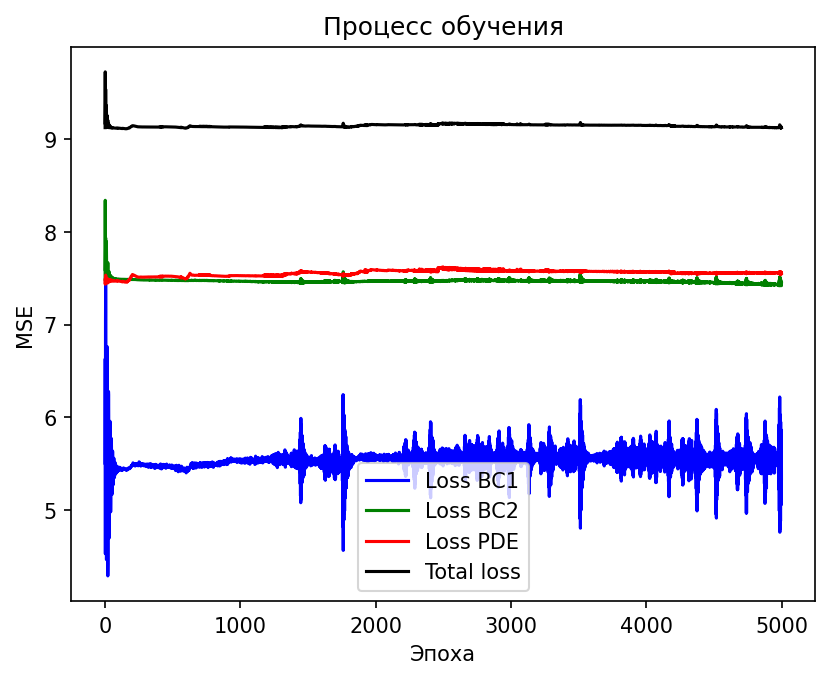

In [113]:
plt.figure(dpi=150)
plt.plot(np.log(h_bc1), c='b', label='Loss BC1')
plt.plot(np.log(h_bc2), c='g', label='Loss BC2')
plt.plot(np.log(h_pde), c='r', label='Loss PDE')
plt.plot(np.log(history), c='black', label='Total loss')
plt.ylabel("MSE")
plt.xlabel("Эпоха")
plt.title('Процесс обучения')
plt.legend()
plt.show()

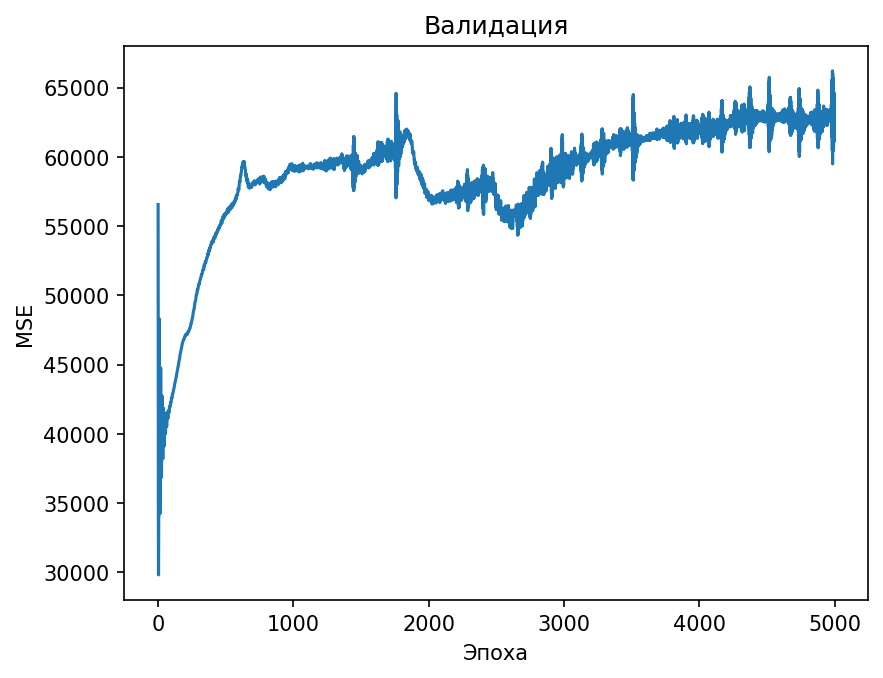

In [114]:
plt.figure(dpi=150)
plt.plot(test_loss)
plt.ylabel("MSE")
plt.xlabel("Эпоха")
plt.title('Валидация')
plt.show()

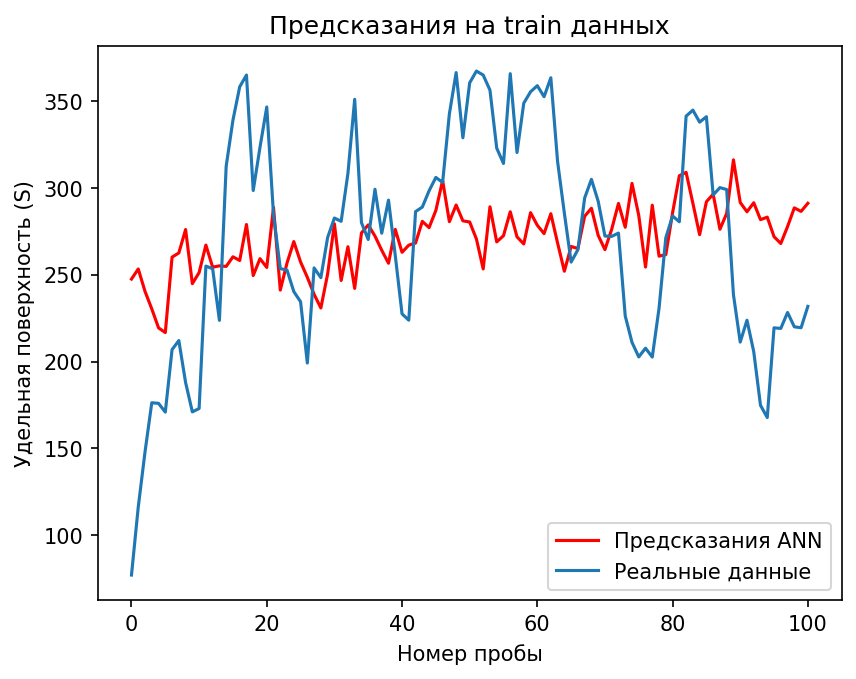

In [184]:
plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания ANN')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

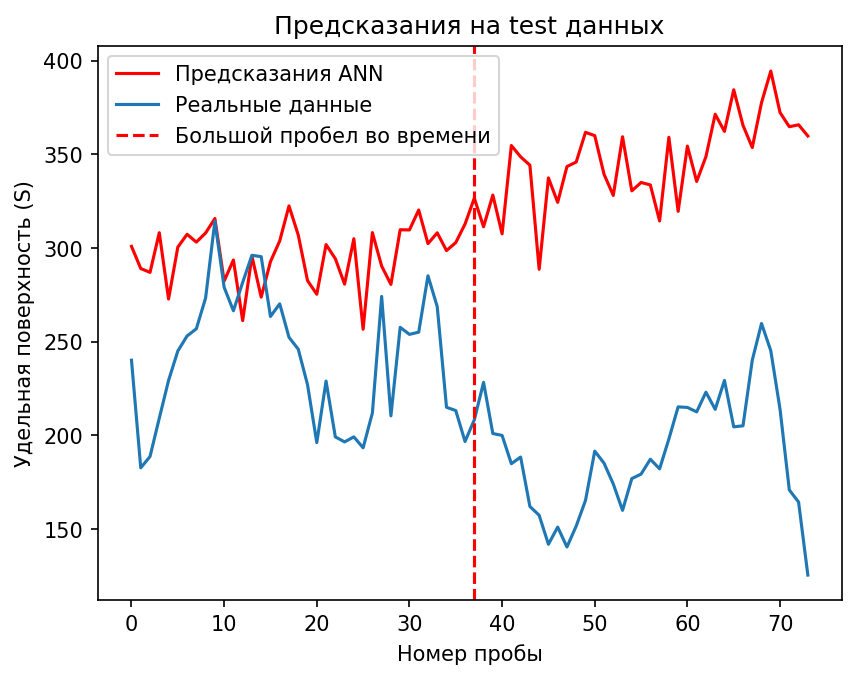

In [185]:
plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания ANN')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

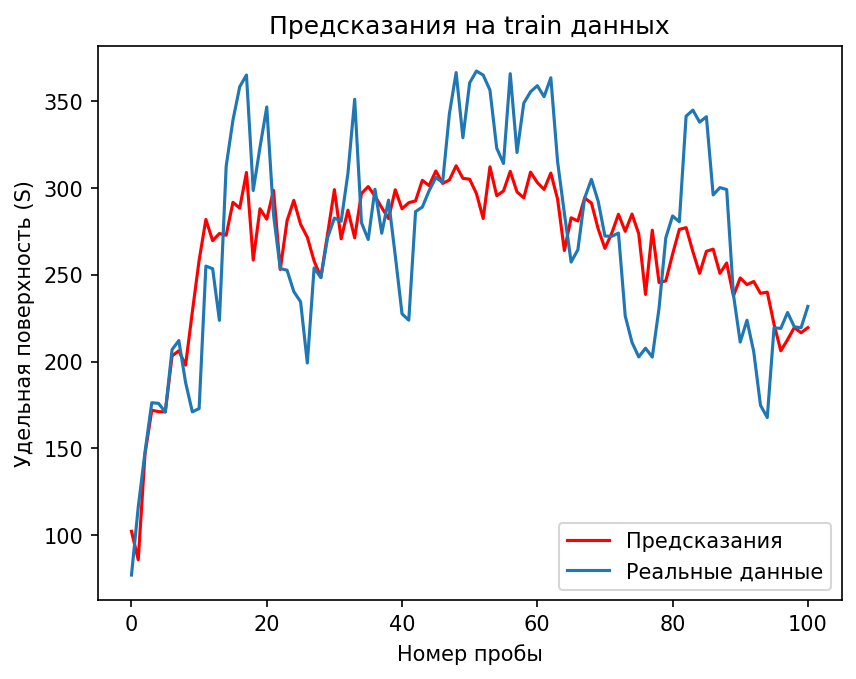

In [115]:
plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

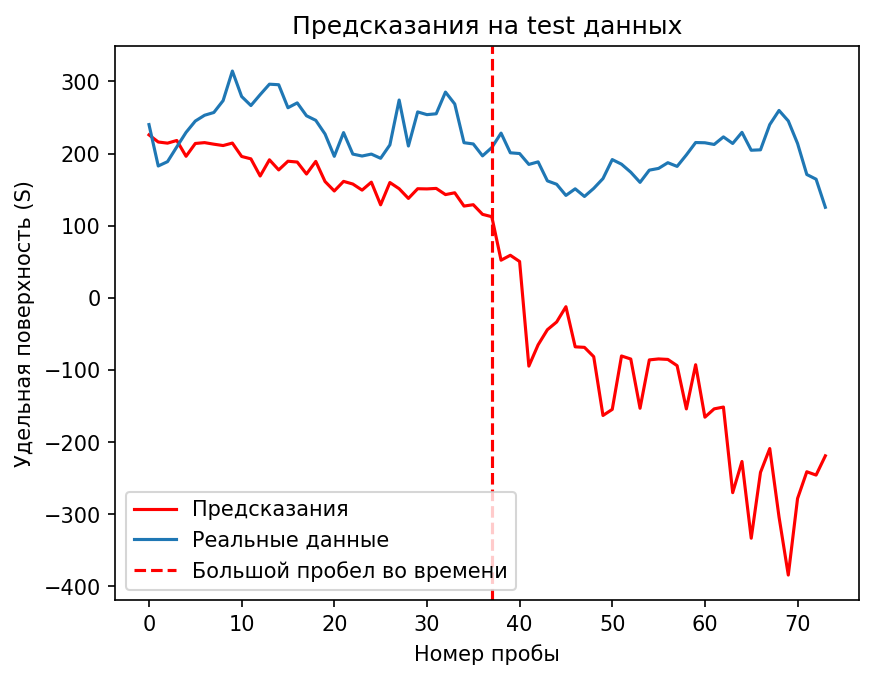

In [140]:
plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [78]:
df.iloc[138+38, 2]

'2023-12-09'

In [74]:
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg],k
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933,0.001963
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314,0.002942
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896,0.001144
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924,0.000815
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450,0.004726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492,0.003424
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621,0.006955
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573,0.006649
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349,0.001333


In [12]:
model(
    torch.tensor([0]).reshape(-1, 1),
    torch.tensor([4.5]).reshape(-1, 1),
    torch.tensor([0.008409]).reshape(-1, 1)
)

tensor([[-2.7074]], grad_fn=<AddmmBackward0>)

In [227]:
pinn = PINN_v2()

checkpoint = torch.load(os.path.join('.', 'best_pinn.pt'))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN_v2(
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)

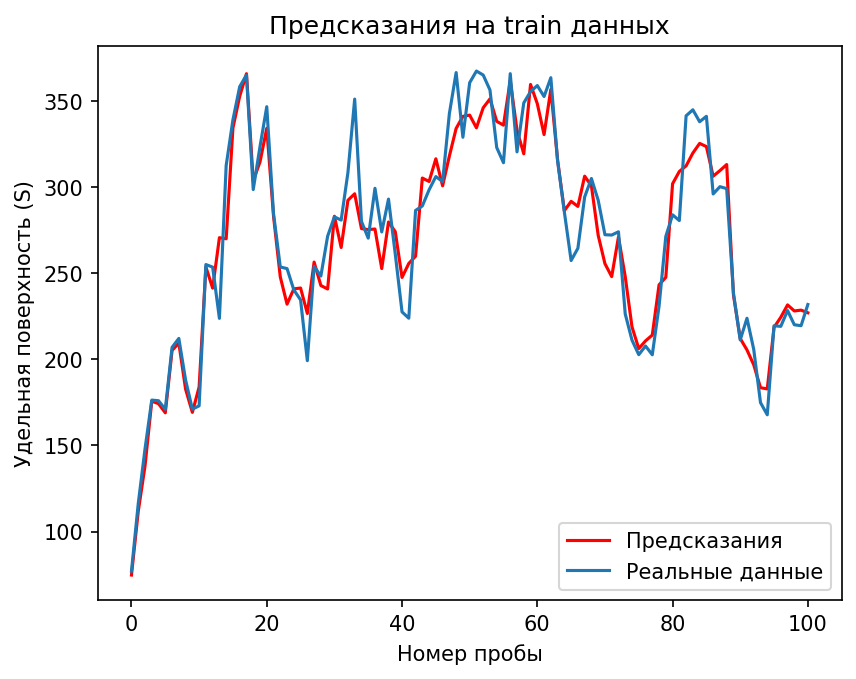

In [136]:
plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

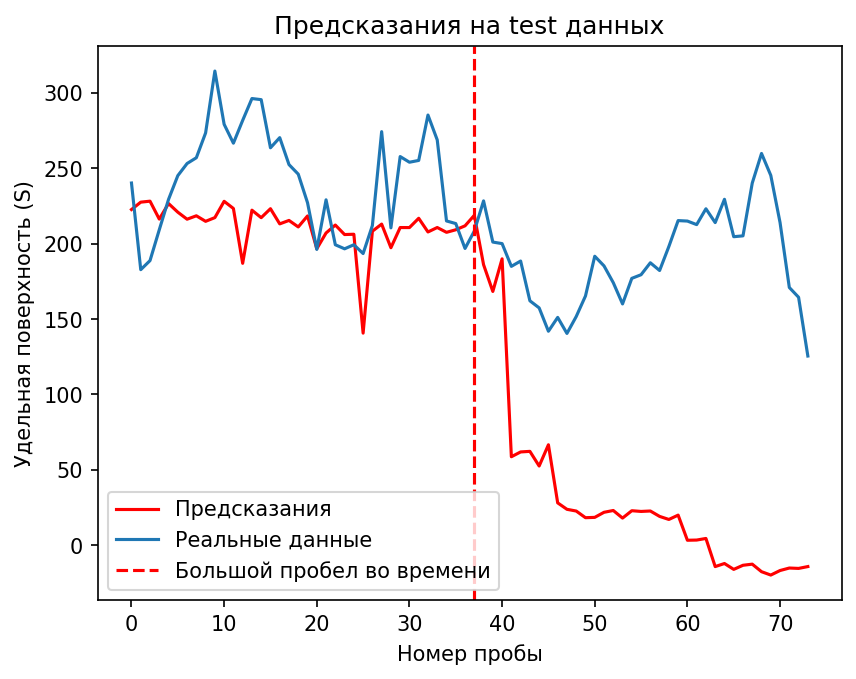

In [137]:
plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

# Обучение модели с k

In [222]:
from loss.pinn_loss_k import pinn_loss_v2
from networks.PINN_k import PINN_k

In [170]:
print(torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1).shape,
torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1).shape,
torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1).shape,
torch.tensor(data["k_bc1_train"], dtype=torch.float32).reshape(-1, 1).shape,
torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1).shape, )

torch.Size([101, 1]) torch.Size([101, 1]) torch.Size([101, 1]) torch.Size([175, 1]) torch.Size([101, 1])


In [179]:
# model = PINN_k()
# model = PINN_v2(k=0.00189)

optimizer = optim.Adam(model.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(3_000):
    model.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        model,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
        torch.tensor(data["k_pde_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["k_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["k_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["k_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=2.0, 
        lambda_bc1=1.0, 
        lambda_bc2=3.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} ")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = model(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        torch.tensor(data['k_bc2_test']),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 7602.788 
Loss PDE: 1710.998 | Loss BC1: 242.826 | Loss BC2: 1312.656
--------------------------------------------------
Epoch 100 | Loss: 7597.208 
Epoch 200 | Loss: 7597.273 
Epoch 300 | Loss: 7591.378 
Epoch 400 | Loss: 7591.740 
Epoch 500 | Loss: 7591.355 
Epoch 600 | Loss: 7593.222 
Epoch 700 | Loss: 7585.715 
Epoch 800 | Loss: 7581.715 
Epoch 900 | Loss: 7577.809 
Epoch 1000 | Loss: 7578.699 
Loss PDE: 1714.557 | Loss BC1: 244.074 | Loss BC2: 1301.837
--------------------------------------------------
Epoch 1100 | Loss: 7574.478 
Epoch 1200 | Loss: 7566.053 
Epoch 1300 | Loss: 7571.634 
Epoch 1400 | Loss: 7566.199 
Epoch 1500 | Loss: 7558.952 
Epoch 1600 | Loss: 7572.260 
Epoch 1700 | Loss: 7559.826 
Epoch 1800 | Loss: 7572.518 
Epoch 1900 | Loss: 7548.900 
Epoch 2000 | Loss: 7544.762 
Loss PDE: 1716.094 | Loss BC1: 243.326 | Loss BC2: 1289.749
--------------------------------------------------
Epoch 2100 | Loss: 7567.132 
E

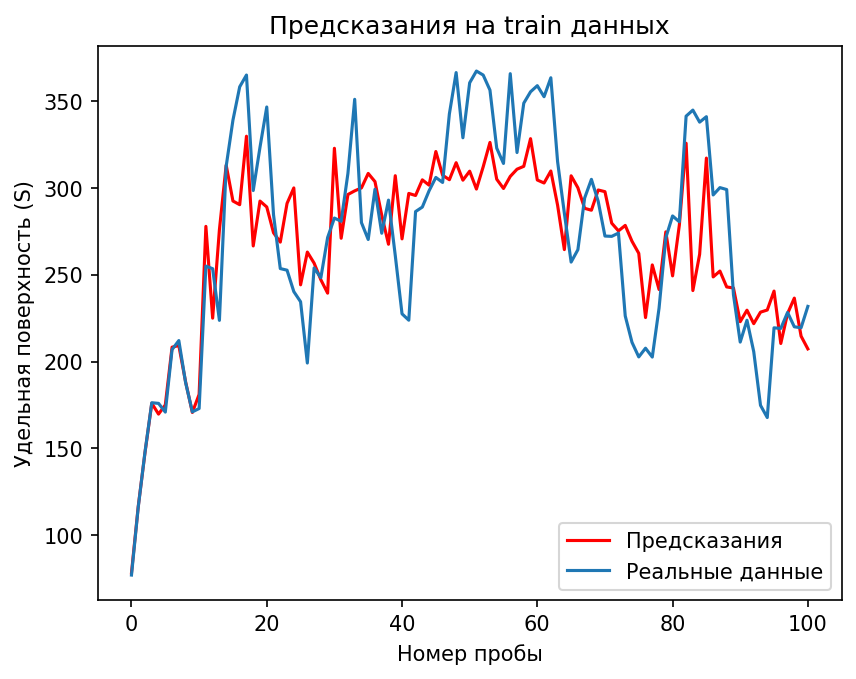

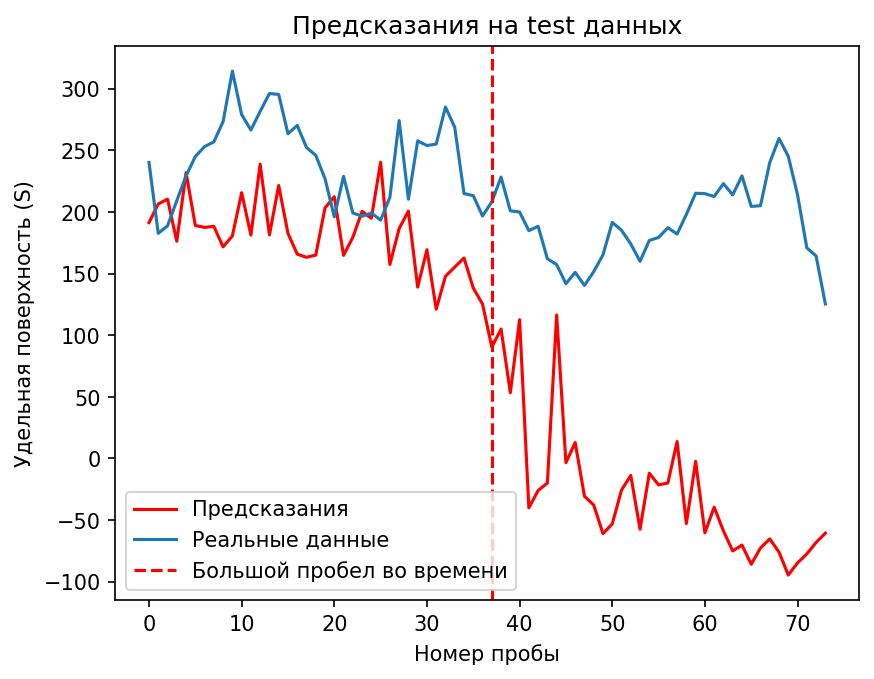

In [180]:
plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        torch.tensor(data['k_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(model(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        torch.tensor(data['k_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

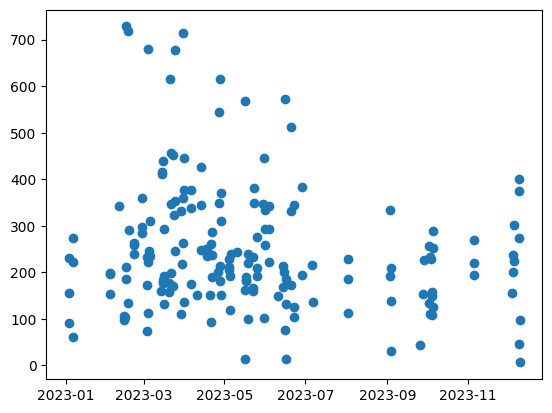

In [154]:
plt.scatter(df['average_time'], df['S_[m2/kg]'])

# Оптимизация k

R2

In [ ]:
def objective(trial):
    k = trial.suggest_float('k', 5e-4, 3e-3)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(50_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем R^2
    r2_1 = r2_score(
        torch.tensor(data["S_bc1_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred1.detach().numpy()
        )
    r2_2 = r2_score(
        torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred2.detach().numpy()
        )

    # Берем среднее
    r2 = np.mean([r2_1,r2_2])

    return r2

In [11]:
study = optuna.create_study(study_name="find_optimal_k", direction="maximize")

[I 2026-05-22 16:23:34,148] A new study created in memory with name: find_optimal_k


5e-4, 3e-3

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 359469678592.000 | k = 0.003
Epoch 100 | Loss: 157995.422 | k = 0.003
Epoch 200 | Loss: 5022851.500 | k = 0.003
Epoch 300 | Loss: 68945664.000 | k = 0.003
Epoch 400 | Loss: 106484.797 | k = 0.003
Epoch 500 | Loss: 100467.352 | k = 0.003
Epoch 600 | Loss: 95713.797 | k = 0.003
Epoch 700 | Loss: 95699.094 | k = 0.003
Epoch 800 | Loss: 95688.062 | k = 0.003
Epoch 900 | Loss: 95678.312 | k = 0.003
Epoch 1000 | Loss: 95664.000 | k = 0.003
Epoch 1100 | Loss: 95653.125 | k = 0.003
Epoch 1200 | Loss: 95640.094 | k = 0.003
Epoch 1300 | Loss: 95625.156 | k = 0.003
Epoch 1400 | Loss: 95607.422 | k = 0.003
Epoch 1500 | Loss: 95590.656 | k = 0.003
Epoch 1600 | Loss: 95572.664 | k = 0.003
Epoch 1700 | Loss: 95553.812 | k = 0.003
Epoch 1800 | Loss: 95531.070 | k = 0.003
Epoch 1900 | Loss: 95509.922 | k = 0.003
Epoch 2000 | Loss: 95488.938 | k = 0.003
Epoch 2100 | Loss: 95462.805 | k = 0.003
Epoch 2200 | Loss: 95436.219 | k = 0.003
Epoch 2300 | L

[I 2026-05-22 16:29:29,522] Trial 0 finished with value: -0.013924002647399902 and parameters: {'k': 0.0025801687266729495}. Best is trial 0 with value: -0.013924002647399902.


Лучший k: 0.0025801687266729495
Лучший R^2: -0.013924002647399902
Время выполнения поиска оптимального параметра: 350.12 секунд


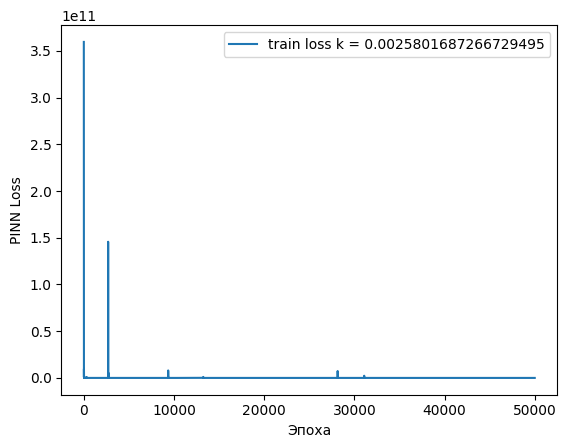

In [12]:
start_time = time.time()
study.optimize(objective, n_trials=1) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

4e-3, 1

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 313214369792.000 | k = 0.944
Epoch 100 | Loss: 888979.625 | k = 0.944
Epoch 200 | Loss: 84203968.000 | k = 0.944
Epoch 300 | Loss: 21205014.000 | k = 0.944
Epoch 400 | Loss: 355898.438 | k = 0.944
Epoch 500 | Loss: 600248.250 | k = 0.944
Epoch 600 | Loss: 347295.719 | k = 0.944
Epoch 700 | Loss: 347232.375 | k = 0.944
Epoch 800 | Loss: 347176.250 | k = 0.944
Epoch 900 | Loss: 27945200.000 | k = 0.944
Epoch 1000 | Loss: 4394654.500 | k = 0.944
Epoch 1100 | Loss: 21870494.000 | k = 0.944
Epoch 1200 | Loss: 348060.688 | k = 0.944
Epoch 1300 | Loss: 347409.531 | k = 0.944
Epoch 1400 | Loss: 54968944.000 | k = 0.944
Epoch 1500 | Loss: 349633.562 | k = 0.944
Epoch 1600 | Loss: 1646405.750 | k = 0.944
Epoch 1700 | Loss: 13323244.000 | k = 0.944
Epoch 1800 | Loss: 28881564.000 | k = 0.944
Epoch 1900 | Loss: 347950.438 | k = 0.944
Epoch 2000 | Loss: 346742.469 | k = 0.944
Epoch 2100 | Loss: 346389.812 | k = 0.944
Epoch 2200 | Loss: 472090.

[I 2026-05-22 01:31:35,071] Trial 0 finished with value: -0.46906954050064087 and parameters: {'k': 0.9435990536881762}. Best is trial 0 with value: -0.46906954050064087.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 5033860096.000 | k = 0.097
Epoch 100 | Loss: 2552777.250 | k = 0.097
Epoch 200 | Loss: 234627.953 | k = 0.097
Epoch 300 | Loss: 3982101.750 | k = 0.097
Epoch 400 | Loss: 640097.688 | k = 0.097
Epoch 500 | Loss: 188601.656 | k = 0.097
Epoch 600 | Loss: 102433.641 | k = 0.097
Epoch 700 | Loss: 98705.375 | k = 0.097
Epoch 800 | Loss: 98688.500 | k = 0.097
Epoch 900 | Loss: 98673.547 | k = 0.097
Epoch 1000 | Loss: 98653.312 | k = 0.097
Epoch 1100 | Loss: 98637.609 | k = 0.097
Epoch 1200 | Loss: 98611.766 | k = 0.097
Epoch 1300 | Loss: 98593.797 | k = 0.097
Epoch 1400 | Loss: 98574.195 | k = 0.097
Epoch 1500 | Loss: 98544.562 | k = 0.097
Epoch 1600 | Loss: 98517.109 | k = 0.097
Epoch 1700 | Loss: 98486.938 | k = 0.097
Epoch 1800 | Loss: 98456.719 | k = 0.097
Epoch 1900 | Loss: 98424.258 | k = 0.097
Epoch 2000 | Loss: 98390.812 | k = 0.097
Epoch 2100 | Loss: 466475.781 | k = 0.097
Epoch 2200 | Loss: 99536.461 | k = 0.097
Epoch 2300 | Lo

[I 2026-05-22 01:34:50,827] Trial 1 finished with value: -0.011344969272613525 and parameters: {'k': 0.09699490943001722}. Best is trial 1 with value: -0.011344969272613525.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 100744511488.000 | k = 0.358
Epoch 100 | Loss: 168382.266 | k = 0.358
Epoch 200 | Loss: 1743023.500 | k = 0.358
Epoch 300 | Loss: 53906984.000 | k = 0.358
Epoch 400 | Loss: 315937.250 | k = 0.358
Epoch 500 | Loss: 140675.188 | k = 0.358
Epoch 600 | Loss: 138069.656 | k = 0.358
Epoch 700 | Loss: 138049.406 | k = 0.358
Epoch 800 | Loss: 138026.906 | k = 0.358
Epoch 900 | Loss: 138003.766 | k = 0.358
Epoch 1000 | Loss: 137976.203 | k = 0.358
Epoch 1100 | Loss: 5015716.000 | k = 0.358
Epoch 1200 | Loss: 138581.625 | k = 0.358
Epoch 1300 | Loss: 138554.250 | k = 0.358
Epoch 1400 | Loss: 358760.250 | k = 0.358
Epoch 1500 | Loss: 8320702.000 | k = 0.358
Epoch 1600 | Loss: 138645.891 | k = 0.358
Epoch 1700 | Loss: 138517.156 | k = 0.358
Epoch 1800 | Loss: 8481241.000 | k = 0.358
Epoch 1900 | Loss: 146008.375 | k = 0.358
Epoch 2000 | Loss: 138468.094 | k = 0.358
Epoch 2100 | Loss: 138427.125 | k = 0.358
Epoch 2200 | Loss: 205503184.000 | k

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 9300056064.000 | k = 0.838
Epoch 100 | Loss: 13169798.000 | k = 0.838
Epoch 200 | Loss: 16557856.000 | k = 0.838
Epoch 300 | Loss: 8341835.500 | k = 0.838
Epoch 400 | Loss: 439029.938 | k = 0.838
Epoch 500 | Loss: 301877.656 | k = 0.838
Epoch 600 | Loss: 301847.281 | k = 0.838
Epoch 700 | Loss: 301820.406 | k = 0.838
Epoch 800 | Loss: 301788.562 | k = 0.838
Epoch 900 | Loss: 2255670.000 | k = 0.838
Epoch 1000 | Loss: 302682.594 | k = 0.838
Epoch 1100 | Loss: 302228.812 | k = 0.838
Epoch 1200 | Loss: 1432523264.000 | k = 0.838
Epoch 1300 | Loss: 323747.062 | k = 0.838
Epoch 1400 | Loss: 303526.844 | k = 0.838
Epoch 1500 | Loss: 302138.906 | k = 0.838
Epoch 1600 | Loss: 302548.188 | k = 0.838
Epoch 1700 | Loss: 301518.344 | k = 0.838
Epoch 1800 | Loss: 403868.875 | k = 0.838
Epoch 1900 | Loss: 300789.875 | k = 0.838
Epoch 2000 | Loss: 307039.875 | k = 0.838
Epoch 2100 | Loss: 305752.562 | k = 0.838
Epoch 2200 | Loss: 300020.875 | k 

[I 2026-05-22 01:57:59,116] Trial 8 finished with value: -13.645926475524902 and parameters: {'k': 0.8380420495300945}. Best is trial 2 with value: -0.0010154247283935547.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 294353024.000 | k = 0.369
Epoch 100 | Loss: 61186248.000 | k = 0.369
Epoch 200 | Loss: 3731895.500 | k = 0.369
Epoch 300 | Loss: 381160.625 | k = 0.369
Epoch 400 | Loss: 1179014.500 | k = 0.369
Epoch 500 | Loss: 141195.797 | k = 0.369
Epoch 600 | Loss: 141163.266 | k = 0.369
Epoch 700 | Loss: 141151.984 | k = 0.369
Epoch 800 | Loss: 141140.312 | k = 0.369
Epoch 900 | Loss: 141127.609 | k = 0.369
Epoch 1000 | Loss: 141113.484 | k = 0.369
Epoch 1100 | Loss: 66560632.000 | k = 0.369
Epoch 1200 | Loss: 141837.812 | k = 0.369
Epoch 1300 | Loss: 141318.125 | k = 0.369
Epoch 1400 | Loss: 141936.125 | k = 0.369
Epoch 1500 | Loss: 146717.859 | k = 0.369
Epoch 1600 | Loss: 141202.969 | k = 0.369
Epoch 1700 | Loss: 141170.188 | k = 0.369
Epoch 1800 | Loss: 141077.500 | k = 0.369
Epoch 1900 | Loss: 140998.297 | k = 0.369
Epoch 2000 | Loss: 140931.547 | k = 0.369
Epoch 2100 | Loss: 140879.922 | k = 0.369
Epoch 2200 | Loss: 1763581.500 | k = 0.

[I 2026-05-22 02:01:13,642] Trial 9 finished with value: -4.783960819244385 and parameters: {'k': 0.36868141836046014}. Best is trial 2 with value: -0.0010154247283935547.


Лучший k: 0.35767177647639864
Лучший R^2: -0.0010154247283935547
Время выполнения поиска оптимального параметра: 1974.83 секунд


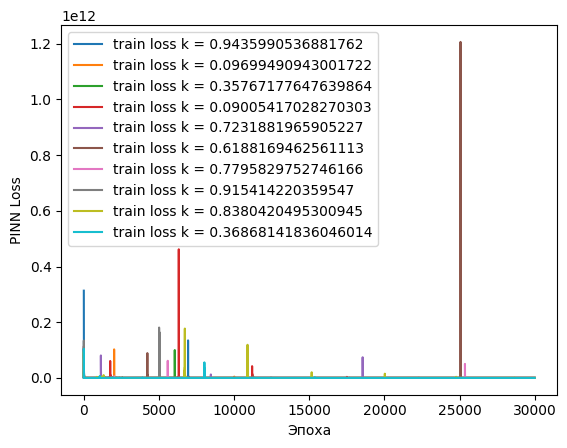

In [33]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

0.01, 1

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 45532344320.000 | k = 0.056
Epoch 100 | Loss: 1273346.500 | k = 0.056
Epoch 200 | Loss: 202970.703 | k = 0.056
Epoch 300 | Loss: 280384.812 | k = 0.056
Epoch 400 | Loss: 1464620.875 | k = 0.056
Epoch 500 | Loss: 132946.109 | k = 0.056
Epoch 600 | Loss: 149188.234 | k = 0.056
Epoch 700 | Loss: 98862.703 | k = 0.056
Epoch 800 | Loss: 97379.117 | k = 0.056
Epoch 900 | Loss: 97370.125 | k = 0.056
Epoch 1000 | Loss: 97360.406 | k = 0.056
Epoch 1100 | Loss: 97353.391 | k = 0.056
Epoch 1200 | Loss: 97342.969 | k = 0.056
Epoch 1300 | Loss: 97333.109 | k = 0.056
Epoch 1400 | Loss: 97323.484 | k = 0.056
Epoch 1500 | Loss: 97313.594 | k = 0.056
Epoch 1600 | Loss: 97299.828 | k = 0.056
Epoch 1700 | Loss: 97288.719 | k = 0.056
Epoch 1800 | Loss: 97273.336 | k = 0.056
Epoch 1900 | Loss: 97260.562 | k = 0.056
Epoch 2000 | Loss: 97247.758 | k = 0.056
Epoch 2100 | Loss: 97231.922 | k = 0.056
Epoch 2200 | Loss: 97216.672 | k = 0.056
Epoch 2300 | Lo

[I 2026-05-22 02:13:50,126] Trial 0 finished with value: -1.504765510559082 and parameters: {'k': 0.05564832364328041}. Best is trial 0 with value: -1.504765510559082.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 1358325504.000 | k = 0.771
Epoch 100 | Loss: 276099.562 | k = 0.771
Epoch 200 | Loss: 5800840.500 | k = 0.771
Epoch 300 | Loss: 10349791.000 | k = 0.771
Epoch 400 | Loss: 57725248.000 | k = 0.771
Epoch 500 | Loss: 5460680.000 | k = 0.771
Epoch 600 | Loss: 273621.938 | k = 0.771
Epoch 700 | Loss: 273585.188 | k = 0.771
Epoch 800 | Loss: 273555.094 | k = 0.771
Epoch 900 | Loss: 6003919.500 | k = 0.771
Epoch 1000 | Loss: 561379.375 | k = 0.771
Epoch 1100 | Loss: 545327.438 | k = 0.771
Epoch 1200 | Loss: 273835.219 | k = 0.771
Epoch 1300 | Loss: 273763.812 | k = 0.771
Epoch 1400 | Loss: 273674.656 | k = 0.771
Epoch 1500 | Loss: 273565.281 | k = 0.771
Epoch 1600 | Loss: 273418.844 | k = 0.771
Epoch 1700 | Loss: 273234.219 | k = 0.771
Epoch 1800 | Loss: 273007.031 | k = 0.771
Epoch 1900 | Loss: 1597566.875 | k = 0.771
Epoch 2000 | Loss: 278213.625 | k = 0.771
Epoch 2100 | Loss: 273245.594 | k = 0.771
Epoch 2200 | Loss: 273052.656 | k = 

[I 2026-05-22 02:17:06,423] Trial 1 finished with value: -1.8519172668457031 and parameters: {'k': 0.7712311546580839}. Best is trial 0 with value: -1.504765510559082.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 38606094336.000 | k = 0.801
Epoch 100 | Loss: 685405.938 | k = 0.801
Epoch 200 | Loss: 1666426.375 | k = 0.801
Epoch 300 | Loss: 759770.000 | k = 0.801
Epoch 400 | Loss: 612074.250 | k = 0.801
Epoch 500 | Loss: 286438.719 | k = 0.801
Epoch 600 | Loss: 286398.406 | k = 0.801
Epoch 700 | Loss: 286372.375 | k = 0.801
Epoch 800 | Loss: 286338.094 | k = 0.801
Epoch 900 | Loss: 286302.531 | k = 0.801
Epoch 1000 | Loss: 288038.000 | k = 0.801
Epoch 1100 | Loss: 286392.469 | k = 0.801
Epoch 1200 | Loss: 286344.438 | k = 0.801
Epoch 1300 | Loss: 286271.344 | k = 0.801
Epoch 1400 | Loss: 2701730.500 | k = 0.801
Epoch 1500 | Loss: 312512.031 | k = 0.801
Epoch 1600 | Loss: 285861.625 | k = 0.801
Epoch 1700 | Loss: 285613.094 | k = 0.801
Epoch 1800 | Loss: 2439233.750 | k = 0.801
Epoch 1900 | Loss: 285118.219 | k = 0.801
Epoch 2000 | Loss: 284769.312 | k = 0.801
Epoch 2100 | Loss: 288708.562 | k = 0.801
Epoch 2200 | Loss: 237987760.000 | k = 0

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 80010543104.000 | k = 0.372
Epoch 100 | Loss: 56706128.000 | k = 0.372
Epoch 200 | Loss: 207049.422 | k = 0.372
Epoch 300 | Loss: 6174890.500 | k = 0.372
Epoch 400 | Loss: 24420746.000 | k = 0.372
Epoch 500 | Loss: 141489.703 | k = 0.372
Epoch 600 | Loss: 600053.875 | k = 0.372
Epoch 700 | Loss: 141245.562 | k = 0.372
Epoch 800 | Loss: 141209.156 | k = 0.372
Epoch 900 | Loss: 141196.500 | k = 0.372
Epoch 1000 | Loss: 141174.719 | k = 0.372
Epoch 1100 | Loss: 141158.125 | k = 0.372
Epoch 1200 | Loss: 141136.281 | k = 0.372
Epoch 1300 | Loss: 141115.750 | k = 0.372
Epoch 1400 | Loss: 141096.562 | k = 0.372
Epoch 1500 | Loss: 141073.906 | k = 0.372
Epoch 1600 | Loss: 141050.500 | k = 0.372
Epoch 1700 | Loss: 141026.172 | k = 0.372
Epoch 1800 | Loss: 141001.234 | k = 0.372
Epoch 1900 | Loss: 140974.656 | k = 0.372
Epoch 2000 | Loss: 140945.750 | k = 0.372
Epoch 2100 | Loss: 321078.531 | k = 0.372
Epoch 2200 | Loss: 142108.734 | k = 0.

[I 2026-05-22 02:39:47,777] Trial 8 finished with value: -0.0019254088401794434 and parameters: {'k': 0.37161674963531854}. Best is trial 8 with value: -0.0019254088401794434.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 143868493824.000 | k = 0.853
Epoch 100 | Loss: 22630308.000 | k = 0.853
Epoch 200 | Loss: 1572927.750 | k = 0.853
Epoch 300 | Loss: 813462.062 | k = 0.853
Epoch 400 | Loss: 836139.250 | k = 0.853
Epoch 500 | Loss: 308311.625 | k = 0.853
Epoch 600 | Loss: 308258.688 | k = 0.853
Epoch 700 | Loss: 308230.375 | k = 0.853
Epoch 800 | Loss: 308206.844 | k = 0.853
Epoch 900 | Loss: 308170.594 | k = 0.853
Epoch 1000 | Loss: 308133.812 | k = 0.853
Epoch 1100 | Loss: 308090.062 | k = 0.853
Epoch 1200 | Loss: 3568184.000 | k = 0.853
Epoch 1300 | Loss: 309064.344 | k = 0.853
Epoch 1400 | Loss: 317339.031 | k = 0.853
Epoch 1500 | Loss: 308657.594 | k = 0.853
Epoch 1600 | Loss: 308593.812 | k = 0.853
Epoch 1700 | Loss: 308511.906 | k = 0.853
Epoch 1800 | Loss: 308398.562 | k = 0.853
Epoch 1900 | Loss: 659620.625 | k = 0.853
Epoch 2000 | Loss: 308025.781 | k = 0.853
Epoch 2100 | Loss: 24483460.000 | k = 0.853
Epoch 2200 | Loss: 308050.000 | k = 

[I 2026-05-22 02:42:59,211] Trial 9 finished with value: -0.34117400646209717 and parameters: {'k': 0.8532489620836924}. Best is trial 8 with value: -0.0019254088401794434.


Лучший k: 0.37161674963531854
Лучший R^2: -0.0019254088401794434
Время выполнения поиска оптимального параметра: 1946.79 секунд


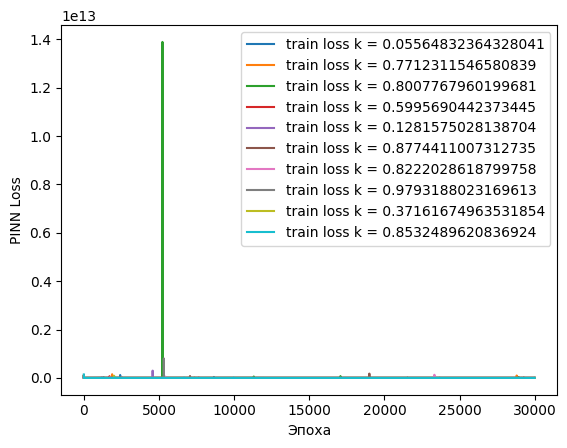

In [36]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

0, 5

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 20751675392.000 | k = 0.894
Epoch 100 | Loss: 1035190.125 | k = 0.894
Epoch 200 | Loss: 11499917.000 | k = 0.894
Epoch 300 | Loss: 16244512.000 | k = 0.894
Epoch 400 | Loss: 7098599.000 | k = 0.894
Epoch 500 | Loss: 390018.250 | k = 0.894
Epoch 600 | Loss: 324553.125 | k = 0.894
Epoch 700 | Loss: 324514.812 | k = 0.894
Epoch 800 | Loss: 324468.344 | k = 0.894
Epoch 900 | Loss: 784039.000 | k = 0.894
Epoch 1000 | Loss: 325500.438 | k = 0.894
Epoch 1100 | Loss: 325675.656 | k = 0.894
Epoch 1200 | Loss: 3626716.500 | k = 0.894
Epoch 1300 | Loss: 438467264.000 | k = 0.894
Epoch 1400 | Loss: 53345600.000 | k = 0.894
Epoch 1500 | Loss: 4009123.500 | k = 0.894
Epoch 1600 | Loss: 383765.688 | k = 0.894
Epoch 1700 | Loss: 325498.844 | k = 0.894
Epoch 1800 | Loss: 325231.969 | k = 0.894
Epoch 1900 | Loss: 324919.969 | k = 0.894
Epoch 2000 | Loss: 324581.312 | k = 0.894
Epoch 2100 | Loss: 324249.375 | k = 0.894
Epoch 2200 | Loss: 1589471.250

[I 2026-05-22 02:52:42,935] Trial 0 finished with value: -0.7007180452346802 and parameters: {'k': 0.8935148790107206}. Best is trial 0 with value: -0.7007180452346802.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 8171719680.000 | k = 3.290
Epoch 100 | Loss: 4804148.500 | k = 3.290
Epoch 200 | Loss: 1785356.000 | k = 3.290
Epoch 300 | Loss: 1728459.125 | k = 3.290
Epoch 400 | Loss: 1631177.000 | k = 3.290
Epoch 500 | Loss: 1597626.000 | k = 3.290
Epoch 600 | Loss: 10677777.000 | k = 3.290
Epoch 700 | Loss: 44769164.000 | k = 3.290
Epoch 800 | Loss: 1592082.500 | k = 3.290
Epoch 900 | Loss: 1585797.000 | k = 3.290
Epoch 1000 | Loss: 1585644.625 | k = 3.290
Epoch 1100 | Loss: 1585476.000 | k = 3.290
Epoch 1200 | Loss: 1585300.750 | k = 3.290
Epoch 1300 | Loss: 1585075.000 | k = 3.290
Epoch 1400 | Loss: 1584843.250 | k = 3.290
Epoch 1500 | Loss: 1584599.750 | k = 3.290
Epoch 1600 | Loss: 1584291.875 | k = 3.290
Epoch 1700 | Loss: 1583954.125 | k = 3.290
Epoch 1800 | Loss: 1583528.000 | k = 3.290
Epoch 1900 | Loss: 1582867.000 | k = 3.290
Epoch 2000 | Loss: 1581931.750 | k = 3.290
Epoch 2100 | Loss: 1580595.500 | k = 3.290
Epoch 2200 | Loss: 15

[I 2026-05-22 02:55:58,808] Trial 1 finished with value: -81.6447525024414 and parameters: {'k': 3.2900882300030387}. Best is trial 0 with value: -0.7007180452346802.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 208564158464.000 | k = 4.028
Epoch 100 | Loss: 4435567.500 | k = 4.028
Epoch 200 | Loss: 2613751.500 | k = 4.028
Epoch 300 | Loss: 10302457.000 | k = 4.028
Epoch 400 | Loss: 7103512.000 | k = 4.028
Epoch 500 | Loss: 2152857.250 | k = 4.028
Epoch 600 | Loss: 2074249.250 | k = 4.028
Epoch 700 | Loss: 2071404.750 | k = 4.028
Epoch 800 | Loss: 2071220.500 | k = 4.028
Epoch 900 | Loss: 3271189248.000 | k = 4.028
Epoch 1000 | Loss: 2155784.750 | k = 4.028
Epoch 1100 | Loss: 2073541.375 | k = 4.028
Epoch 1200 | Loss: 2073741.875 | k = 4.028
Epoch 1300 | Loss: 2073270.875 | k = 4.028
Epoch 1400 | Loss: 2073155.250 | k = 4.028
Epoch 1500 | Loss: 2073023.250 | k = 4.028
Epoch 1600 | Loss: 2072867.750 | k = 4.028
Epoch 1700 | Loss: 2072713.625 | k = 4.028
Epoch 1800 | Loss: 2080245.125 | k = 4.028
Epoch 1900 | Loss: 2072357.750 | k = 4.028
Epoch 2000 | Loss: 2072146.250 | k = 4.028
Epoch 2100 | Loss: 2071905.875 | k = 4.028
Epoch 2200 | Loss

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 23105300480.000 | k = 3.238
Epoch 100 | Loss: 4546861.000 | k = 3.238
Epoch 200 | Loss: 10098442.000 | k = 3.238
Epoch 300 | Loss: 3506650112.000 | k = 3.238
Epoch 400 | Loss: 23656696.000 | k = 3.238
Epoch 500 | Loss: 1558559.875 | k = 3.238
Epoch 600 | Loss: 1554647.250 | k = 3.238
Epoch 700 | Loss: 1554508.000 | k = 3.238
Epoch 800 | Loss: 36079896.000 | k = 3.238
Epoch 900 | Loss: 1555861.375 | k = 3.238
Epoch 1000 | Loss: 1556458.000 | k = 3.238
Epoch 1100 | Loss: 1553806.000 | k = 3.238
Epoch 1200 | Loss: 1854256.375 | k = 3.238
Epoch 1300 | Loss: 1553026.000 | k = 3.238
Epoch 1400 | Loss: 1552491.875 | k = 3.238
Epoch 1500 | Loss: 1551906.125 | k = 3.238
Epoch 1600 | Loss: 1551226.250 | k = 3.238
Epoch 1700 | Loss: 2896616.500 | k = 3.238
Epoch 1800 | Loss: 1550605.875 | k = 3.238
Epoch 1900 | Loss: 1549667.250 | k = 3.238
Epoch 2000 | Loss: 1548770.625 | k = 3.238
Epoch 2100 | Loss: 1547872.750 | k = 3.238
Epoch 2200 | Los

[I 2026-05-22 03:18:07,705] Trial 8 finished with value: -79.88156127929688 and parameters: {'k': 3.2379857218070676}. Best is trial 6 with value: -0.00020688772201538086.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 53068890112.000 | k = 0.748
Epoch 100 | Loss: 104430896.000 | k = 0.748
Epoch 200 | Loss: 6055741.500 | k = 0.748
Epoch 300 | Loss: 3481862.000 | k = 0.748
Epoch 400 | Loss: 338675.312 | k = 0.748
Epoch 500 | Loss: 364701.000 | k = 0.748
Epoch 600 | Loss: 264199.812 | k = 0.748
Epoch 700 | Loss: 264173.156 | k = 0.748
Epoch 800 | Loss: 264147.188 | k = 0.748
Epoch 900 | Loss: 264115.844 | k = 0.748
Epoch 1000 | Loss: 264080.781 | k = 0.748
Epoch 1100 | Loss: 264041.812 | k = 0.748
Epoch 1200 | Loss: 199369056.000 | k = 0.748
Epoch 1300 | Loss: 1094026.375 | k = 0.748
Epoch 1400 | Loss: 265160.688 | k = 0.748
Epoch 1500 | Loss: 331203.125 | k = 0.748
Epoch 1600 | Loss: 265012.219 | k = 0.748
Epoch 1700 | Loss: 264929.281 | k = 0.748
Epoch 1800 | Loss: 264824.969 | k = 0.748
Epoch 1900 | Loss: 264691.250 | k = 0.748
Epoch 2000 | Loss: 264521.750 | k = 0.748
Epoch 2100 | Loss: 264316.375 | k = 0.748
Epoch 2200 | Loss: 279243.812 | k 

[I 2026-05-22 03:21:21,935] Trial 9 finished with value: -1.4742021560668945 and parameters: {'k': 0.747755027717224}. Best is trial 6 with value: -0.00020688772201538086.


Лучший k: 0.33466800302734523
Лучший R^2: -0.00020688772201538086
Время выполнения поиска оптимального параметра: 1914.32 секунд


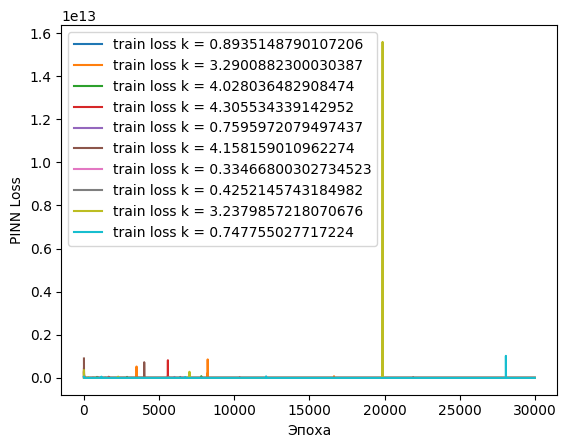

In [39]:
start_time = time.time()
study.optimize(objective, n_trials=10) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 42950205440.000 | k = 0.001
Epoch 100 | Loss: 421410.062 | k = 0.001
Epoch 200 | Loss: 69763416.000 | k = 0.001
Epoch 300 | Loss: 96487.336 | k = 0.001
Epoch 400 | Loss: 1320808.250 | k = 0.001
Epoch 500 | Loss: 96390.523 | k = 0.001
Epoch 600 | Loss: 96387.547 | k = 0.001
Epoch 700 | Loss: 96384.969 | k = 0.001
Epoch 800 | Loss: 96384.047 | k = 0.001
Epoch 900 | Loss: 415951.312 | k = 0.001
Epoch 1000 | Loss: 25040882.000 | k = 0.001
Epoch 1100 | Loss: 103449.875 | k = 0.001
Epoch 1200 | Loss: 96384.977 | k = 0.001
Epoch 1300 | Loss: 96380.422 | k = 0.001
Epoch 1400 | Loss: 119617.172 | k = 0.001
Epoch 1500 | Loss: 1328037.750 | k = 0.001
Epoch 1600 | Loss: 96388.242 | k = 0.001
Epoch 1700 | Loss: 96383.141 | k = 0.001
Epoch 1800 | Loss: 96375.305 | k = 0.001
Epoch 1900 | Loss: 64058376.000 | k = 0.001
Epoch 2000 | Loss: 104070.688 | k = 0.001
Epoch 2100 | Loss: 96370.125 | k = 0.001
Epoch 2200 | Loss: 96367.836 | k = 0.001
Epoch

[I 2026-05-22 03:30:56,605] Trial 0 finished with value: -0.013925135135650635 and parameters: {'k': 0.0011277830958028427}. Best is trial 0 with value: -0.013925135135650635.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 122918338560.000 | k = 0.003
Epoch 100 | Loss: 7190263.000 | k = 0.003
Epoch 200 | Loss: 115875.523 | k = 0.003
Epoch 300 | Loss: 96279.016 | k = 0.003
Epoch 400 | Loss: 96278.578 | k = 0.003
Epoch 500 | Loss: 852274.375 | k = 0.003
Epoch 600 | Loss: 115415.344 | k = 0.003
Epoch 700 | Loss: 97000.586 | k = 0.003
Epoch 800 | Loss: 96284.734 | k = 0.003
Epoch 900 | Loss: 96284.062 | k = 0.003
Epoch 1000 | Loss: 96282.578 | k = 0.003
Epoch 1100 | Loss: 246741.156 | k = 0.003
Epoch 1200 | Loss: 96883.250 | k = 0.003
Epoch 1300 | Loss: 96283.766 | k = 0.003
Epoch 1400 | Loss: 190546.391 | k = 0.003
Epoch 1500 | Loss: 31206498.000 | k = 0.003
Epoch 1600 | Loss: 123804.656 | k = 0.003
Epoch 1700 | Loss: 495139.375 | k = 0.003
Epoch 1800 | Loss: 135416.688 | k = 0.003
Epoch 1900 | Loss: 96226.062 | k = 0.003
Epoch 2000 | Loss: 96250.086 | k = 0.003
Epoch 2100 | Loss: 136818.922 | k = 0.003
Epoch 2200 | Loss: 96233.656 | k = 0.003
Epoch 23

[I 2026-05-22 03:36:19,270] Trial 1 finished with value: -0.013923883438110352 and parameters: {'k': 0.0026255626857001188}. Best is trial 1 with value: -0.013923883438110352.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 1553816448.000 | k = 0.001
Epoch 100 | Loss: 120446.719 | k = 0.001
Epoch 200 | Loss: 7112046.000 | k = 0.001
Epoch 300 | Loss: 166979.516 | k = 0.001
Epoch 400 | Loss: 343340.125 | k = 0.001
Epoch 500 | Loss: 96301.688 | k = 0.001
Epoch 600 | Loss: 96958.648 | k = 0.001
Epoch 700 | Loss: 96294.938 | k = 0.001
Epoch 800 | Loss: 96295.336 | k = 0.001
Epoch 900 | Loss: 96293.758 | k = 0.001
Epoch 1000 | Loss: 96291.672 | k = 0.001
Epoch 1100 | Loss: 1126388.625 | k = 0.001
Epoch 1200 | Loss: 96335.875 | k = 0.001
Epoch 1300 | Loss: 96287.438 | k = 0.001
Epoch 1400 | Loss: 267532512.000 | k = 0.001
Epoch 1500 | Loss: 104589.578 | k = 0.001
Epoch 1600 | Loss: 96240.359 | k = 0.001
Epoch 1700 | Loss: 96235.945 | k = 0.001
Epoch 1800 | Loss: 96546.922 | k = 0.001
Epoch 1900 | Loss: 96238.312 | k = 0.001
Epoch 2000 | Loss: 96232.070 | k = 0.001
Epoch 2100 | Loss: 96227.641 | k = 0.001
Epoch 2200 | Loss: 96363.172 | k = 0.001
Epoch 2300 |

...

НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 7208421376.000 | k = 0.002
Epoch 100 | Loss: 105820.391 | k = 0.002
Epoch 200 | Loss: 97110.797 | k = 0.002
Epoch 300 | Loss: 222378.844 | k = 0.002
Epoch 400 | Loss: 96306.117 | k = 0.002
Epoch 500 | Loss: 4545210.000 | k = 0.002
Epoch 600 | Loss: 96473.500 | k = 0.002
Epoch 700 | Loss: 96167.180 | k = 0.002
Epoch 800 | Loss: 96162.336 | k = 0.002
Epoch 900 | Loss: 27402708.000 | k = 0.002
Epoch 1000 | Loss: 3025726.250 | k = 0.002
Epoch 1100 | Loss: 96411.562 | k = 0.002
Epoch 1200 | Loss: 264195.625 | k = 0.002
Epoch 1300 | Loss: 97704.086 | k = 0.002
Epoch 1400 | Loss: 96203.883 | k = 0.002
Epoch 1500 | Loss: 153829.125 | k = 0.002
Epoch 1600 | Loss: 96211.023 | k = 0.002
Epoch 1700 | Loss: 99139.938 | k = 0.002
Epoch 1800 | Loss: 27836268.000 | k = 0.002
Epoch 1900 | Loss: 96950.375 | k = 0.002
Epoch 2000 | Loss: 13200966.000 | k = 0.002
Epoch 2100 | Loss: 908865.562 | k = 0.002
Epoch 2200 | Loss: 198610.031 | k = 0.002
Epoch

[I 2026-05-22 05:05:34,970] Trial 18 finished with value: -0.013925254344940186 and parameters: {'k': 0.0015370357937780931}. Best is trial 4 with value: -0.01392221450805664.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 85591826432.000 | k = 0.001
Epoch 100 | Loss: 360799392.000 | k = 0.001
Epoch 200 | Loss: 119117.617 | k = 0.001
Epoch 300 | Loss: 752343.750 | k = 0.001
Epoch 400 | Loss: 96242.633 | k = 0.001
Epoch 500 | Loss: 96233.570 | k = 0.001
Epoch 600 | Loss: 96232.656 | k = 0.001
Epoch 700 | Loss: 96226.070 | k = 0.001
Epoch 800 | Loss: 1665598.000 | k = 0.001
Epoch 900 | Loss: 96299.500 | k = 0.001
Epoch 1000 | Loss: 96249.695 | k = 0.001
Epoch 1100 | Loss: 96253.180 | k = 0.001
Epoch 1200 | Loss: 96248.438 | k = 0.001
Epoch 1300 | Loss: 5111424.500 | k = 0.001
Epoch 1400 | Loss: 96279.242 | k = 0.001
Epoch 1500 | Loss: 96245.961 | k = 0.001
Epoch 1600 | Loss: 735070.812 | k = 0.001
Epoch 1700 | Loss: 97578.719 | k = 0.001
Epoch 1800 | Loss: 834226.750 | k = 0.001
Epoch 1900 | Loss: 1414527.500 | k = 0.001
Epoch 2000 | Loss: 96297.195 | k = 0.001
Epoch 2100 | Loss: 96265.297 | k = 0.001
Epoch 2200 | Loss: 96264.008 | k = 0.001
Epoch 230

[I 2026-05-22 05:10:43,955] Trial 19 finished with value: -0.013934016227722168 and parameters: {'k': 0.0009748555167661027}. Best is trial 4 with value: -0.01392221450805664.


Лучший k: 0.0008946736012594615
Лучший R^2: -0.01392221450805664
Время выполнения поиска оптимального параметра: 6312.30 секунд


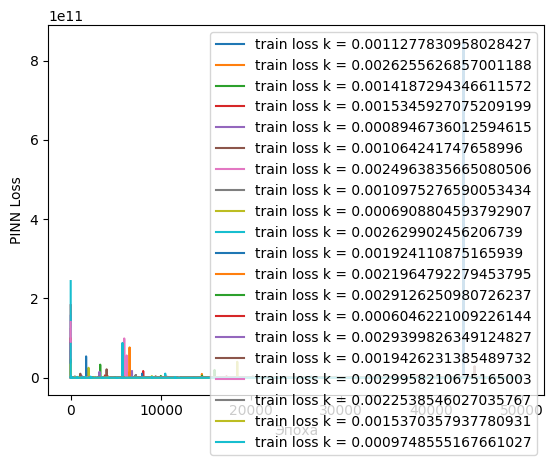

In [42]:
start_time = time.time()
study.optimize(objective, n_trials=20) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

поиск по первым эпохам

In [ ]:
def objective(trial):
    k = trial.suggest_float('k', 5e-2, 1.2)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(2_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

            torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
            lambda_ic=1.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем R^2
    r2_1 = r2_score(
        torch.tensor(data["S_bc1_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred1.detach().numpy()
        )
    r2_2 = r2_score(
        torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1).numpy(), 
        pred2.detach().numpy()
        )

    # Берем среднее
    r2 = np.mean([r2_1,r2_2])

    return r2

In [128]:
BEST_MODEL_PATH = "best_pinn.pt"

def objective(trial):
    k = trial.suggest_float('k', 1e-4, 6e-3)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    best_epoch_loss = float("inf")
    history = []
    h_pde = []
    h_bc1 = []
    h_bc2 = []
    test_loss = []

    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(20_000):
        model.train()
        optimizer.zero_grad()

        loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

            torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=2.0, 
            lambda_bc1=1.0, 
            lambda_bc2=3.0,
            lambda_ic=0.0,
        )

        loss.backward()
        optimizer.step()

        if loss.item() < best_epoch_loss:
            best_epoch_loss = loss.item()

            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'k': k,
                'epoch': epoch,
                'loss': best_epoch_loss,
            }, "best_epoch_model.pt")


        history.append(loss.item())
        h_pde.append(loss_pde)
        h_bc1.append(loss_bc1)
        h_bc2.append(loss_bc2)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.5f}")
        
        if epoch % 1000 == 0:
            print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
            print('-' * 50)
    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')

    pred = model(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        ).detach()

    r2 = r2_score(data['S_bc2_train'], pred)

    try:
        best_value = trial.study.best_value
    except ValueError:
        best_value = -float("inf")

    if r2 > best_value:

        torch.save({
            'model_state_dict': model.state_dict(),
            'k': k,
            'r2': r2,
        }, BEST_MODEL_PATH)

        print(f'ЛУЧШАЯ МОДЕЛЬ СОХРАНЕНА | R2 = {r2:.5f}')

    return r2

In [129]:
study = optuna.create_study(study_name="find_optimal_k", direction="maximize")

[I 2026-05-25 15:50:43,491] A new study created in memory with name: find_optimal_k


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 231385.391 | k = 0.00109
Loss PDE: 0.659 | Loss BC1: 0.290 | Loss BC2: 77127.930
--------------------------------------------------
Epoch 100 | Loss: 14332.840 | k = 0.00109
Epoch 200 | Loss: 13551.123 | k = 0.00109
Epoch 300 | Loss: 10346.166 | k = 0.00109
Epoch 400 | Loss: 9293.023 | k = 0.00109
Epoch 500 | Loss: 9134.863 | k = 0.00109
Epoch 600 | Loss: 9187.191 | k = 0.00109
Epoch 700 | Loss: 9367.347 | k = 0.00109
Epoch 800 | Loss: 9435.028 | k = 0.00109
Epoch 900 | Loss: 9472.705 | k = 0.00109
Epoch 1000 | Loss: 9401.330 | k = 0.00109
Loss PDE: 1803.132 | Loss BC1: 236.820 | Loss BC2: 1852.749
--------------------------------------------------
Epoch 1100 | Loss: 9481.947 | k = 0.00109
Epoch 1200 | Loss: 9408.609 | k = 0.00109
Epoch 1300 | Loss: 9433.033 | k = 0.00109
Epoch 1400 | Loss: 9833.156 | k = 0.00109
Epoch 1500 | Loss: 9583.008 | k = 0.00109
Epoch 1600 | Loss: 9729.941 | k = 0.00109
Epoch 1700 | Loss: 9517.296 | k = 0

[I 2026-05-25 15:53:45,288] Trial 0 finished with value: 0.7174980640411377 and parameters: {'k': 0.0010879176352441941}. Best is trial 0 with value: 0.7174980640411377.


ЛУЧШАЯ МОДЕЛЬ СОХРАНЕНА | R2 = 0.71750
НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 231421.750 | k = 0.00031
Loss PDE: 0.055 | Loss BC1: 0.280 | Loss BC2: 77140.453
--------------------------------------------------
Epoch 100 | Loss: 14415.551 | k = 0.00031
Epoch 200 | Loss: 13470.521 | k = 0.00031
Epoch 300 | Loss: 10837.686 | k = 0.00031
Epoch 400 | Loss: 10038.600 | k = 0.00031
Epoch 500 | Loss: 10112.648 | k = 0.00031
Epoch 600 | Loss: 9569.695 | k = 0.00031
Epoch 700 | Loss: 10101.027 | k = 0.00031
Epoch 800 | Loss: 9625.004 | k = 0.00031
Epoch 900 | Loss: 9630.113 | k = 0.00031
Epoch 1000 | Loss: 9665.553 | k = 0.00031
Loss PDE: 1872.910 | Loss BC1: 319.170 | Loss BC2: 1866.854
--------------------------------------------------
Epoch 1100 | Loss: 9596.169 | k = 0.00031
Epoch 1200 | Loss: 9700.614 | k = 0.00031
Epoch 1300 | Loss: 9795.254 | k = 0.00031
Epoch 1400 | Loss: 9735.883 | k = 0.00031
Epoch 1500 | Loss: 9734.992 | k = 0.00031
Epoch 1600 | Loss: 9652.944 | k = 0

[I 2026-05-25 15:56:41,156] Trial 1 finished with value: 0.7468786239624023 and parameters: {'k': 0.00030756490828753007}. Best is trial 1 with value: 0.7468786239624023.


ЛУЧШАЯ МОДЕЛЬ СОХРАНЕНА | R2 = 0.74688
НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 231357.938 | k = 0.00545
Loss PDE: 16.702 | Loss BC1: 0.222 | Loss BC2: 77108.102
--------------------------------------------------
Epoch 100 | Loss: 14015.904 | k = 0.00545
Epoch 200 | Loss: 13025.672 | k = 0.00545
Epoch 300 | Loss: 10263.415 | k = 0.00545
Epoch 400 | Loss: 8545.615 | k = 0.00545
Epoch 500 | Loss: 8740.122 | k = 0.00545
Epoch 600 | Loss: 9112.386 | k = 0.00545
Epoch 700 | Loss: 8625.572 | k = 0.00545
Epoch 800 | Loss: 8880.328 | k = 0.00545
Epoch 900 | Loss: 8853.700 | k = 0.00545
Epoch 1000 | Loss: 9009.275 | k = 0.00545
Loss PDE: 1631.554 | Loss BC1: 258.216 | Loss BC2: 1829.317
--------------------------------------------------
Epoch 1100 | Loss: 8963.594 | k = 0.00545
Epoch 1200 | Loss: 8999.188 | k = 0.00545
Epoch 1300 | Loss: 9193.483 | k = 0.00545
Epoch 1400 | Loss: 9094.528 | k = 0.00545
Epoch 1500 | Loss: 9000.658 | k = 0.00545
Epoch 1600 | Loss: 9146.810 | k = 0.0

...

[I 2026-05-25 20:39:07,145] Trial 45 finished with value: 0.8329480886459351 and parameters: {'k': 0.004015731275547463}. Best is trial 16 with value: 0.9253089427947998.


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 231272.625 | k = 0.00496
Loss PDE: 13.851 | Loss BC1: 0.176 | Loss BC2: 77081.586
--------------------------------------------------
Epoch 100 | Loss: 13874.846 | k = 0.00496
Epoch 200 | Loss: 13174.634 | k = 0.00496
Epoch 300 | Loss: 9960.756 | k = 0.00496
Epoch 400 | Loss: 8886.810 | k = 0.00496
Epoch 500 | Loss: 9157.534 | k = 0.00496
Epoch 600 | Loss: 8665.372 | k = 0.00496
Epoch 700 | Loss: 8951.143 | k = 0.00496
Epoch 800 | Loss: 8870.314 | k = 0.00496
Epoch 900 | Loss: 8912.074 | k = 0.00496
Epoch 1000 | Loss: 8975.562 | k = 0.00496
Loss PDE: 1606.369 | Loss BC1: 191.546 | Loss BC2: 1857.093
--------------------------------------------------
Epoch 1100 | Loss: 9085.804 | k = 0.00496
Epoch 1200 | Loss: 9018.646 | k = 0.00496
Epoch 1300 | Loss: 9099.678 | k = 0.00496
Epoch 1400 | Loss: 9007.817 | k = 0.00496
Epoch 1500 | Loss: 9001.291 | k = 0.00496
Epoch 1600 | Loss: 9055.578 | k = 0.00496
Epoch 1700 | Loss: 9083.478 | k = 0

[W 2026-05-25 22:20:54,658] Trial 46 failed with parameters: {'k': 0.004960017075552553} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/pw/9v35zrks1gj89m9hgtttxv1c0000gn/T/ipykernel_50251/3004359274.py", line 46, in objective
    loss.backward()
  File "/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/torch/autograd/graph.py", line 865, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine 

Epoch 15000 | Loss: 8106.075 | k = 0.00496
Loss PDE: 1710.722 | Loss BC1: 419.632 | Loss BC2: 1421.666
--------------------------------------------------


KeyboardInterrupt: 

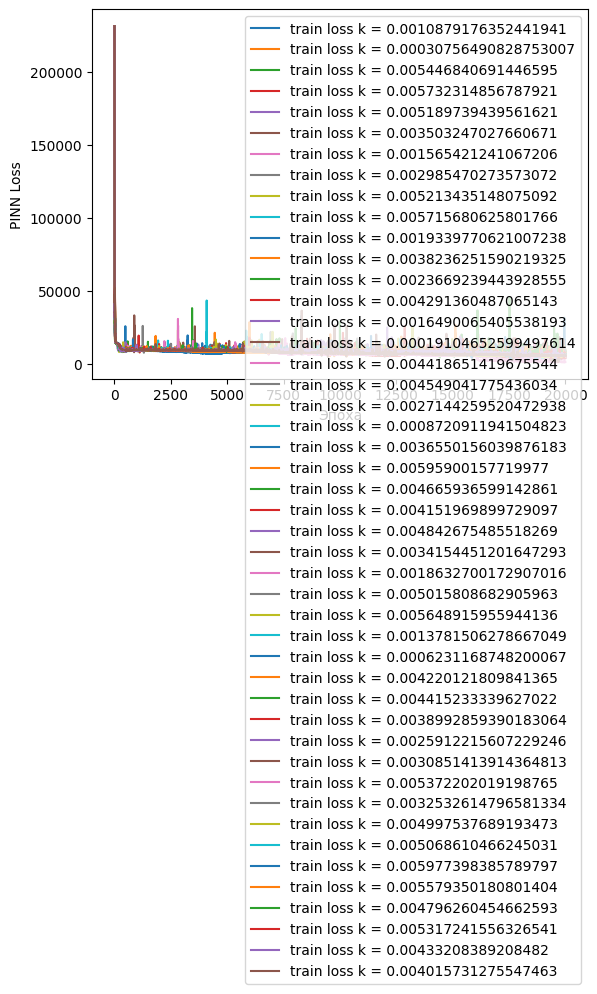

In [130]:
start_time = time.time()
study.optimize(objective, n_trials=60) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший R^2:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Задание параметров системы
v = 0.001       # Скорость переноса
k = 0.5       # Коэффициент кинетики
S_max = 10.0  # Максимальное значение S
L = 10.0      # Длина расчетной области по z
T_max = 5.0   # Максимальное время моделирования

# 2. Пространственная сетка
Nz = 100                      # Количество точек по пространству
z = np.linspace(0, L, Nz)     # Сетка по z
dz = z[1] - z[0]              # Шаг сетки

# 3. Граничное и начальное условия
S_bound = 5.0                 # Значение S на левой границе (z = 0)
S0 = np.zeros(Nz)             # Начальное распределение S(z) при t = 0
S0[0] = S_bound               # Согласование границы

# 4. Правая часть системы ОДУ (метод прямых)
def pde_system(t, S):
    dSdt = np.zeros_like(S)
    
    # Граничное условие на левой границе z = 0 (фиксированное значение)
    dSdt[0] = 0 
    
    # Направленная разность назад для производной dS/dz (аппроксимация первого порядка)
    # dS/dz ≈ (S[i] - S[i-1]) / dz
    dS_dz = (S[1:] - S[:-1]) / dz
    
    # Вычисление dS/dt для внутренних и граничной правой точек
    dSdt[1:] = -v * dS_dz + k * (S_max - S[1:])
    
    return dSdt
start_time = time.time()
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

# 5. Решение системы аналогом ode45 (RK45)
t_span = (0, T_max)
t_eval = np.linspace(0, T_max, 100) # Точки времени, в которых сохраняем ответ

sol = solve_ivp(pde_system, t_span, S0, method='RK45', t_eval=t_eval)
execution_time = time.time() - start_time

# 6. Визуализация результатов
plt.figure(figsize=(10, 6))
# Построим профили S(z) для нескольких моментов времени
for i in range(0, len(sol.t), 20):
    plt.plot(z, sol.y[:, i], label=f't = {sol.t[i]:.1f}')

plt.title('Эволюция профиля $S(z, t)$')
plt.xlabel('Пространство (z)')
plt.ylabel('Концентрация (S)')
plt.grid(True)
plt.legend()
plt.show()

mse

In [43]:
import torch.nn.functional as F

In [44]:
def objective(trial):
    k = trial.suggest_float('k', 5e-4, 3e-3)
    model = PINN_v2(k=k)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
    for epoch in range(40_000):
        model.train()
        optimizer.zero_grad()

        loss = pinn_loss_v2(
            model,
            torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 
            torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),
            lambda_pde=1.0, 
            lambda_bc1=1.0, 
            lambda_bc2=2.0,
        )

        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {model.k:.3f}")

    plt.plot(history, label=f'train loss k = {k}')
    plt.legend()
    plt.ylabel('PINN Loss')
    plt.xlabel('Эпоха')
    
    # Предсказания в начале мельницы  
    pred1 = model(
        torch.tensor(data["t_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Предсказания в конце мельницы 
    pred2 = model(
        torch.tensor(data["t_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_test"], dtype=torch.float32).reshape(-1, 1),
        )
    
    # Вычисляем mse
    mse = F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred2.detach())


    return mse

In [45]:
study = optuna.create_study(study_name="find_optimal_k", direction="minimize")

[I 2026-05-22 16:06:18,798] A new study created in memory with name: find_optimal_k


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 61546852352.000 | k = 0.003
Epoch 100 | Loss: 47004840.000 | k = 0.003
Epoch 200 | Loss: 10083198.000 | k = 0.003
Epoch 300 | Loss: 96565.398 | k = 0.003
Epoch 400 | Loss: 52567656.000 | k = 0.003
Epoch 500 | Loss: 100704.117 | k = 0.003
Epoch 600 | Loss: 174944.875 | k = 0.003
Epoch 700 | Loss: 1202050.625 | k = 0.003
Epoch 800 | Loss: 102590.469 | k = 0.003
Epoch 900 | Loss: 96336.680 | k = 0.003
Epoch 1000 | Loss: 96337.219 | k = 0.003
Epoch 1100 | Loss: 592270.062 | k = 0.003
Epoch 1200 | Loss: 178495.141 | k = 0.003
Epoch 1300 | Loss: 96296.859 | k = 0.003
Epoch 1400 | Loss: 96301.031 | k = 0.003
Epoch 1500 | Loss: 984967.812 | k = 0.003
Epoch 1600 | Loss: 100376.984 | k = 0.003
Epoch 1700 | Loss: 96318.688 | k = 0.003
Epoch 1800 | Loss: 2235083.250 | k = 0.003
Epoch 1900 | Loss: 615193.938 | k = 0.003
Epoch 2000 | Loss: 96329.977 | k = 0.003
Epoch 2100 | Loss: 97963.008 | k = 0.003
Epoch 2200 | Loss: 96398.734 | k = 0.003
Ep

[I 2026-05-22 16:10:39,739] Trial 0 finished with value: 11663.599609375 and parameters: {'k': 0.0028502750381729494}. Best is trial 0 with value: 11663.599609375.


Лучший k: 0.0028502750381729494
Лучший MSE: 11663.599609375
Время выполнения поиска оптимального параметра: 246.74 секунд


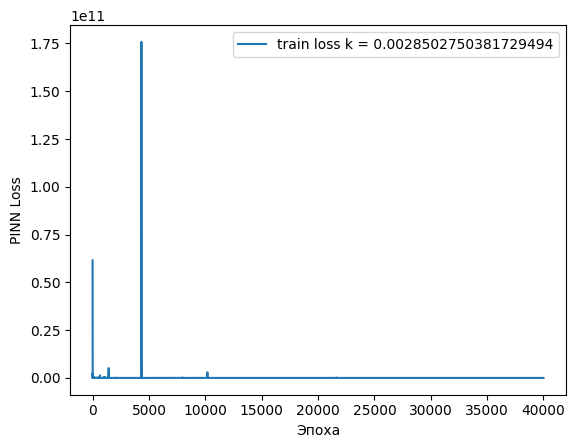

In [46]:
start_time = time.time()
study.optimize(objective, n_trials=1) 
execution_time = time.time() - start_time

print("Лучший k:", study.best_params['k'])
print("Лучший MSE:", study.best_value)
print(f"Время выполнения поиска оптимального параметра: {execution_time:.2f} секунд")

# Confusion matrix

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [197]:
len(data["S_bc2_test"])

74

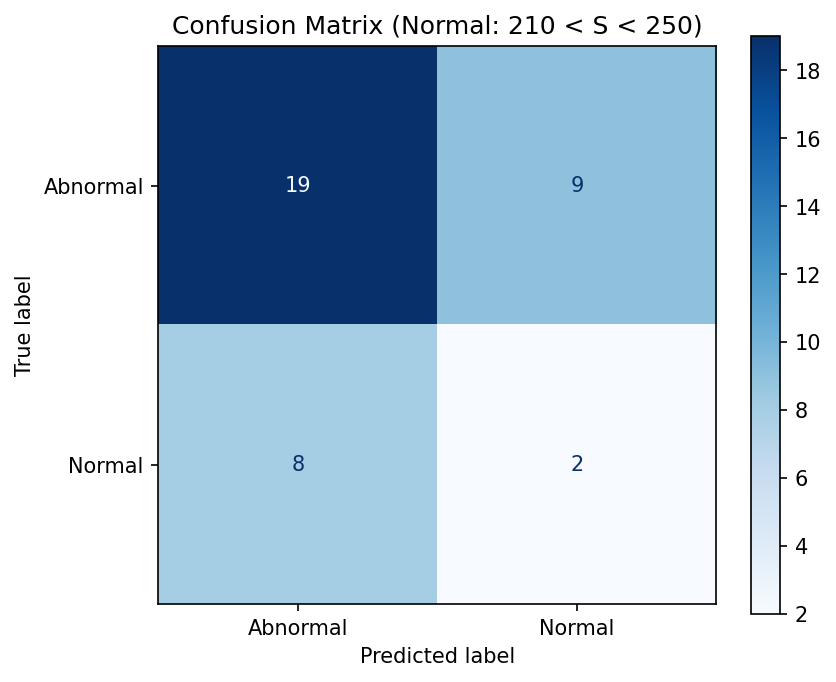

Confusion matrix (rows - true, cols - pred):
         Pred Abnormal  Pred Normal
True Abnormal        19           9
True Normal           8           2


In [59]:
S_true = np.array(data["S_bc2_test"][:38]).flatten()

# Предсказания модели
S_pred = pinn(
    torch.tensor(data['t_bc2_test'][:38]),
    torch.tensor(data['z_bc2_test'][:38]),
    torch.tensor(data['v_bc2_test'][:38]),
    # torch.tensor([0.00001]*len(data['t_bc2_test'])),
    # torch.tensor(data['k_bc2_test']),
).detach().numpy().flatten() 

# Функция бинаризации
def to_binary(S):
    return np.where((S > 210) & (S < 250), 1, 0)

# Преобразуем истинные и предсказанные значения в метки классов
y_true = to_binary(S_true)
y_pred = to_binary(S_pred)

# Построим confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Abnormal', 'Normal'])

# Визуализация
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
disp.plot(ax=ax, values_format='d', cmap='Blues')
ax.set_title('Confusion Matrix (Normal: 210 < S < 250)')
plt.show()

# Вывод численных значений матрицы
print("Confusion matrix (rows - true, cols - pred):")
print("         Pred Abnormal  Pred Normal")
print(f"True Abnormal     {cm[0,0]:5d}       {cm[0,1]:5d}")
print(f"True Normal       {cm[1,0]:5d}       {cm[1,1]:5d}")

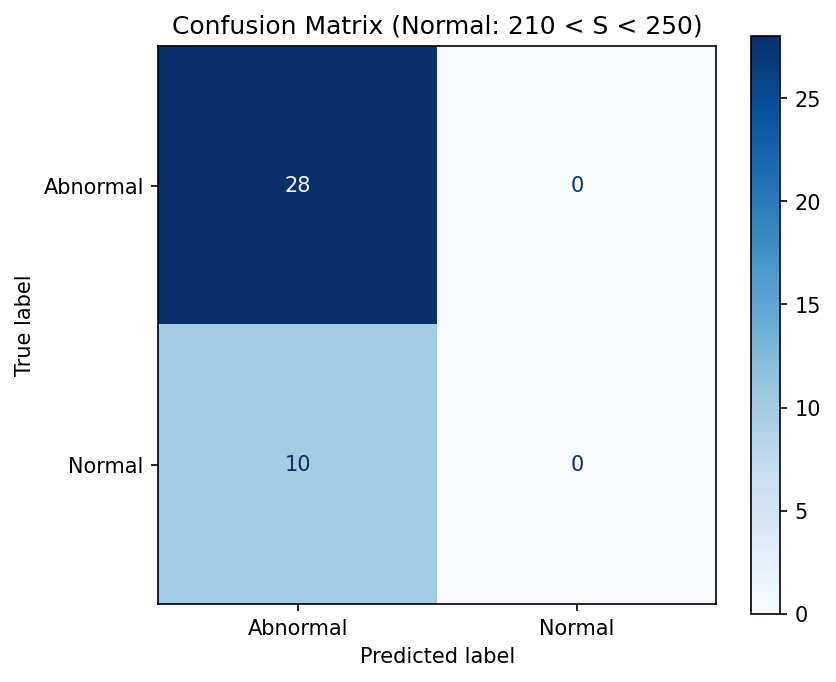

Confusion matrix (rows - true, cols - pred):
         Pred Abnormal  Pred Normal
True Abnormal        28           0
True Normal          10           0


In [246]:
S_true = np.array(data["S_bc2_test"][:38]).flatten()

# Предсказания модели
S_pred = ann(
    torch.tensor(data['t_bc2_test'][:38]),
    torch.tensor(data['z_bc2_test'][:38]),
    torch.tensor(data['v_bc2_test'][:38]),
    # torch.tensor([0.00001]*len(data['t_bc2_test'])),
    # torch.tensor(data['k_bc2_test']),
).detach().numpy().flatten() 

# Функция бинаризации
def to_binary(S):
    return np.where((S > 210) & (S < 250), 1, 0)

# Преобразуем истинные и предсказанные значения в метки классов
y_true = to_binary(S_true)
y_pred = to_binary(S_pred)

# Построим confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Abnormal', 'Normal'])

# Визуализация
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
disp.plot(ax=ax, values_format='d', cmap='Blues')
ax.set_title('Confusion Matrix (Normal: 210 < S < 250)')
plt.show()

# Вывод численных значений матрицы
print("Confusion matrix (rows - true, cols - pred):")
print("         Pred Abnormal  Pred Normal")
print(f"True Abnormal     {cm[0,0]:5d}       {cm[0,1]:5d}")
print(f"True Normal       {cm[1,0]:5d}       {cm[1,1]:5d}")

# Метрики

In [61]:
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)

In [12]:
pinn = PINN_v2()

checkpoint = torch.load(os.path.join('.', 'pinn_2605.pt'))
pinn.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [72]:
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg],k
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933,0.001963
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314,0.002942
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896,0.001144
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924,0.000815
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450,0.004726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492,0.003424
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621,0.006955
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573,0.006649
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349,0.001333


In [66]:
S_true = np.array(data["S_bc2_test"][:38]).flatten()

# Предсказания модели
S_pred = pinn(
    torch.tensor(data['t_bc2_test'][:38]),
    torch.tensor(data['z_bc2_test'][:38]),
    torch.tensor(data['v_bc2_test'][:38]),
    # torch.tensor([0.00001]*len(data['t_bc2_test'])),
    # torch.tensor(data['k_bc2_test']),
).detach().numpy().flatten() 

metrics = {
    "MSE": mean_squared_error(S_true, S_pred),
    "MAE": mean_absolute_error(S_true, S_pred),
    "RMSE": root_mean_squared_error(S_true, S_pred),
}

print("Метрики PINN")
print(f"\n{'= ' * 13}")
print(f"| {'Метрика':<10} | {'Значение':<11} |")
print(f"{'= ' * 13}")
for key, value in metrics.items():
    val_str = f"{value:.6f}" if isinstance(value, (int, float)) and not np.isnan(value) else str(value)
    print(f"| {key:<10} | {val_str:<11} |")
print(f"{'= ' * 13}\n")

Метрики PINN

= = = = = = = = = = = = = 
| Метрика    | Значение    |
= = = = = = = = = = = = = 
| MSE        | 8183.761292 |
| MAE        | 70.776202   |
| RMSE       | 90.464144   |
= = = = = = = = = = = = = 



In [71]:
S_true = np.array(data["S_bc2_test"][:38]).flatten()

# Предсказания модели
S_pred = ann(
    torch.tensor(data['t_bc2_test'][:38]),
    torch.tensor(data['z_bc2_test'][:38]),
    torch.tensor(data['v_bc2_test'][:38]),
    # torch.tensor([0.00001]*len(data['t_bc2_test'])),
    # torch.tensor(data['k_bc2_test']),
).detach().numpy().flatten() 

metrics = {
    "MSE": mean_squared_error(S_true, S_pred),
    "MAE": mean_absolute_error(S_true, S_pred),
    "RMSE": root_mean_squared_error(S_true, S_pred),
}

print("Метрики ANN")
print(f"\n{'= ' * 13}")
print(f"| {'Метрика':<10} | {'Значение':<11} |")
print(f"{'= ' * 13}")
for key, value in metrics.items():
    val_str = f"{value:.6f}" if isinstance(value, (int, float)) and not np.isnan(value) else str(value)
    print(f"| {key:<10} | {val_str:<11} |")
print(f"{'= ' * 13}\n")

Метрики ANN

= = = = = = = = = = = = = 
| Метрика    | Значение    |
= = = = = = = = = = = = = 
| MSE        | 4529.275160 |
| MAE        | 58.896773   |
| RMSE       | 67.299890   |
= = = = = = = = = = = = = 



In [13]:
pinn = PINN_v2()

checkpoint = torch.load(os.path.join('.', 'pinn_2605.pt'))
pinn.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

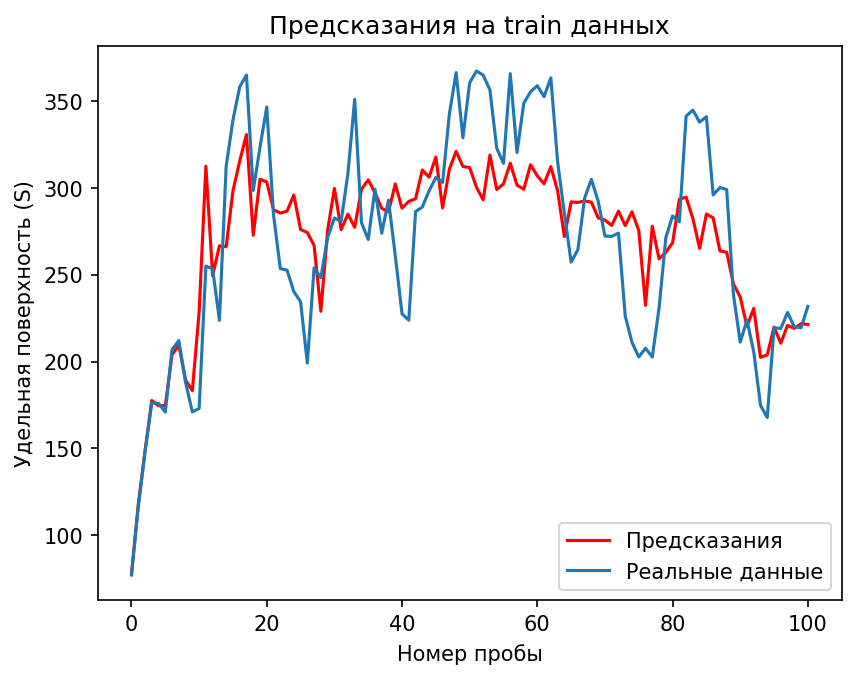

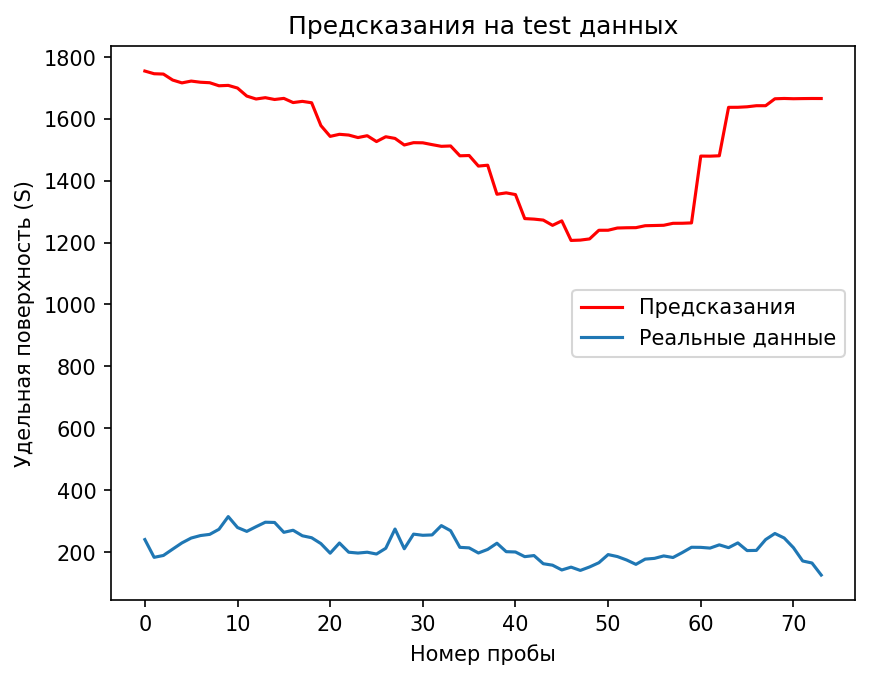

In [14]:
plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_train']),
        torch.tensor(data['z_bc2_train']),
        torch.tensor(data['v_bc2_train']),
        # torch.tensor(data['k_bc2_train']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        # torch.tensor(data['k_bc2_test']),
        ).detach().numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
# plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [72]:
data['t_bc2_test']

[534.7512155907997,
 486.80925196904155,
 479.40617996682624,
 558.9317474532056,
 430.2389302873579,
 524.379496115992,
 552.9289478988073,
 534.1480964425424,
 552.6723023644639,
 590.5601374456484,
 454.92243813891116,
 486.06256941190753,
 386.2857870564903,
 491.9376637737166,
 423.1453195610251,
 481.22151467738064,
 518.8920826673324,
 607.6150068562582,
 531.4864299535133,
 436.535266793817,
 412.6729541111674,
 494.0762136956086,
 467.78203453140065,
 425.78708570289496,
 504.2163518714022,
 354.8624221663204,
 515.654669777293,
 452.6028452179056,
 420.13546421216313,
 515.3817300988403,
 514.854332412628,
 557.8772996045843,
 484.4052752029699,
 505.6539388662417,
 463.6199315274431,
 477.8289298962434,
 502.53435758687004,
 560.8393746978402,
 459.80972046336626,
 521.0032097247079,
 448.01296592111254,
 585.5090091538545,
 555.8046985821812,
 534.7244357911393,
 358.0288054539486,
 506.420220390284,
 434.04805858633125,
 493.2048133145847,
 500.7588776556055,
 561.63692167

LBFGS

In [58]:
pinn = PINN_v2(k=0.00189)

optimizer = optim.AdamW(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(1_000):
    pinn.train()
    optimizer.zero_grad()
    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=1.0, 
        lambda_bc1=0.0, 
        lambda_bc2=0.0,
        lambda_ic=0.0,
    )

    loss.backward()

    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)
    optimizer.step()
    

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test']),
        torch.tensor(data['z_bc2_test']),
        torch.tensor(data['v_bc2_test']),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 2.016 | k = 0.00189
Loss PDE: 2.016 | Loss BC1: 0.305 | Loss BC2: 77152.094
--------------------------------------------------
Epoch 100 | Loss: 0.023 | k = 0.00189
Epoch 200 | Loss: 0.020 | k = 0.00189
Epoch 300 | Loss: 0.019 | k = 0.00189


KeyboardInterrupt: 

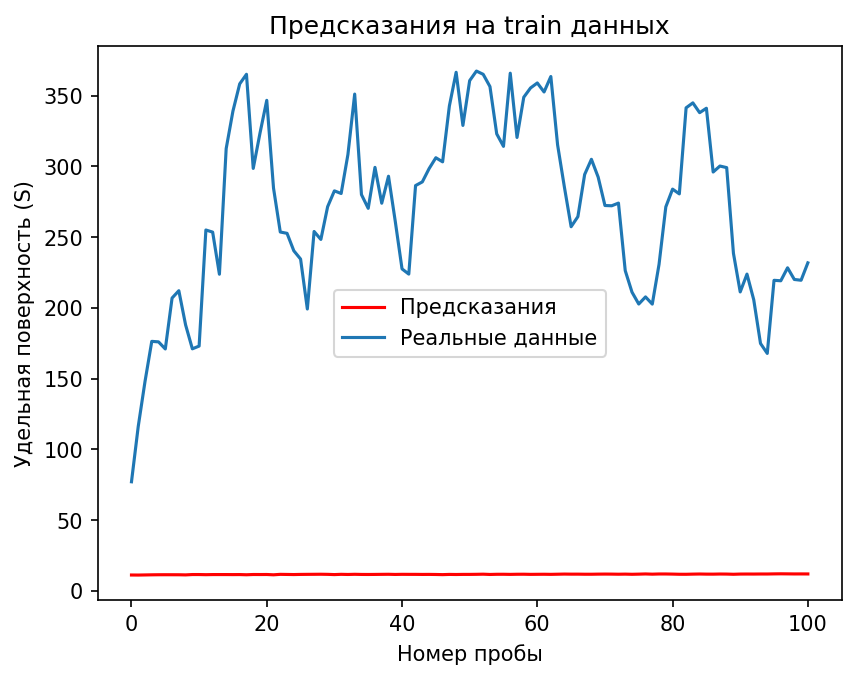

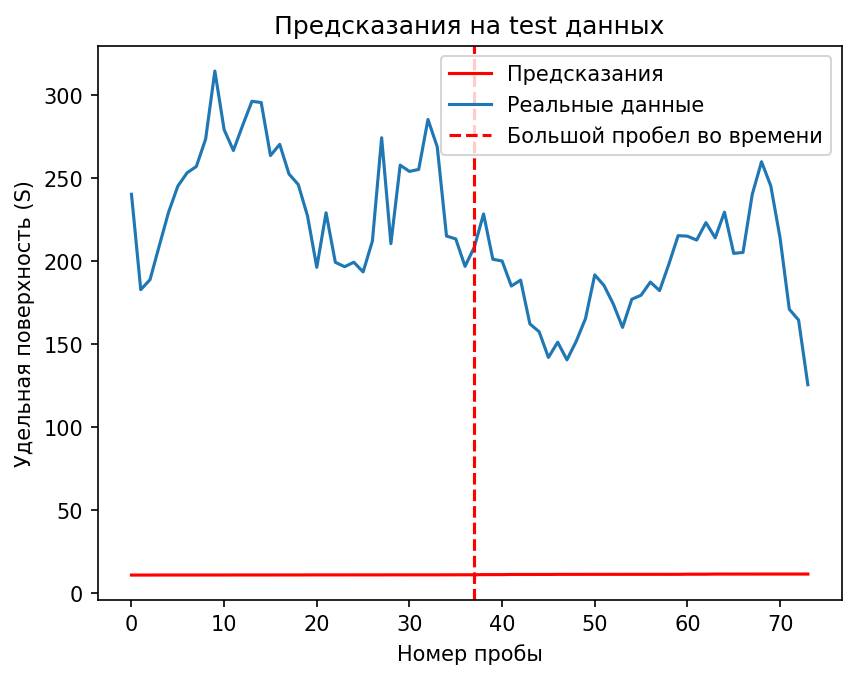

In [59]:
train_pred = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.plot(train_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(test_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [5]:
test = pd.read_csv('data/test_data_not_shuffled.csv')

In [9]:
pinn = PINN_v2()

checkpoint = torch.load(os.path.join('.', 'pinn_0306.pt'))
pinn.load_state_dict(checkpoint["model_state_dict"])

pinn.eval()

PINN_v2(
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [10]:
test

,Unnamed: 0,t,z,Fm,Fl,S,date
0,141,459.80972,4.5,83.7862,49.4,113.541220,2023-08-02 11:36:30
1,142,521.00323,4.5,72.9909,44.0,229.228010,2023-08-02 11:58:30
2,143,448.01297,4.5,104.2654,43.0,185.368560,2023-08-02 12:21:30
3,144,585.50903,4.5,47.7520,46.4,334.797500,2023-09-02 16:14:00
4,145,555.80470,4.5,56.1883,46.4,191.831480,2023-09-02 16:33:30
5,146,534.72440,4.5,64.6422,45.6,208.596160,2023-09-03 09:02:00
6,147,358.02880,4.5,155.1659,43.4,30.915018,2023-09-03 14:20:30
7,148,506.42023,4.5,79.7603,43.3,138.266600,2023-09-03 15:22:30
8,149,434.04807,4.5,54.9028,66.6,44.695030,2023-09-25 14:59:30
9,150,493.20480,4.5,49.5319,58.1,152.373800,2023-09-27 15:29:00


In [11]:
Ore_Density = 2800.0
Liquid_Density = 1300.0
A_pulp = 1.89

In [12]:
Qs = test['Fm'] / Ore_Density
Ql = test['Fl'] / Liquid_Density
test['v'] = (Qs + Ql) / A_pulp

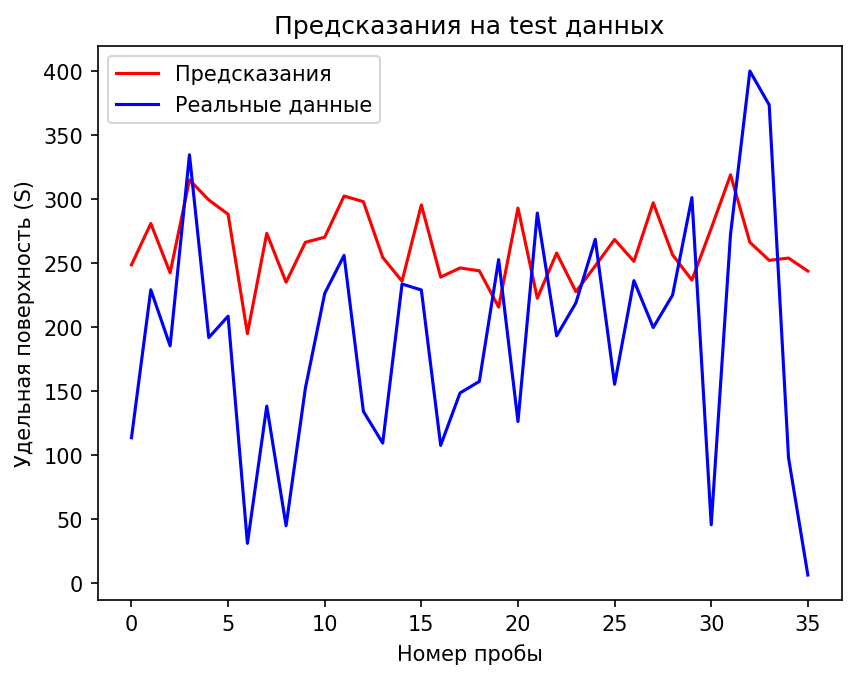

In [18]:


test_pred = pinn(
        torch.tensor(test['t'], dtype=torch.float32),
        torch.tensor(test['z'], dtype=torch.float32),
        torch.tensor(test['v'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.plot(test_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        test["S"],  label='Реальные данные', c='b'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
# plt.axhline(250,
#             linestyle=':', label='Smax')

# plt.axhline(150,
#         linestyle=':', label='Smin')
plt.xlabel("Номер пробы")
plt.legend()
plt.show()